In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## imports

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

## loading Dataset

In [3]:
df = pd.read_csv('/kaggle/input/boston-housing-dataset/BostonHousing.csv')

## Doing basics of data check for data understanding

In [4]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [6]:
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [7]:
size = df.shape
size

(506, 14)

In [8]:
col_list = df.columns.tolist()
col_list

['crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'b',
 'lstat',
 'medv']

## Data Cleaning and Processing and Handling Outliers

In [9]:
# handling the null values
df['rm'] = df['rm'].fillna(df['rm'].mean())
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [10]:
df.describe().round()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0,506.0
mean,4.0,11.0,11.0,0.0,1.0,6.0,69.0,4.0,10.0,408.0,18.0,357.0,13.0,23.0
std,9.0,23.0,7.0,0.0,0.0,1.0,28.0,2.0,9.0,169.0,2.0,91.0,7.0,9.0
min,0.0,0.0,0.0,0.0,0.0,4.0,3.0,1.0,1.0,187.0,13.0,0.0,2.0,5.0
25%,0.0,0.0,5.0,0.0,0.0,6.0,45.0,2.0,4.0,279.0,17.0,375.0,7.0,17.0
50%,0.0,0.0,10.0,0.0,1.0,6.0,78.0,3.0,5.0,330.0,19.0,391.0,11.0,21.0
75%,4.0,12.0,18.0,0.0,1.0,7.0,94.0,5.0,24.0,666.0,20.0,396.0,17.0,25.0
max,89.0,100.0,28.0,1.0,1.0,9.0,100.0,12.0,24.0,711.0,22.0,397.0,38.0,50.0


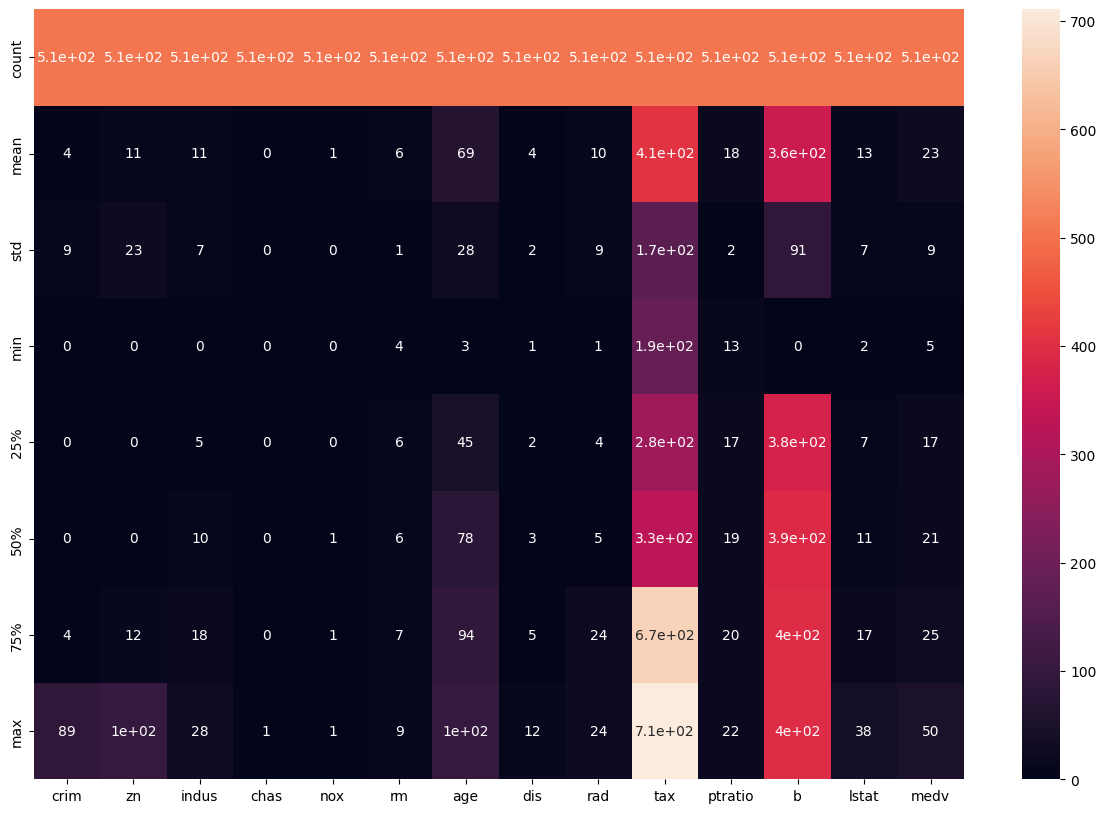

In [11]:
plt.figure(figsize=(15, 10))
sns.heatmap(data=df.describe().round(), annot=True)
plt.show()

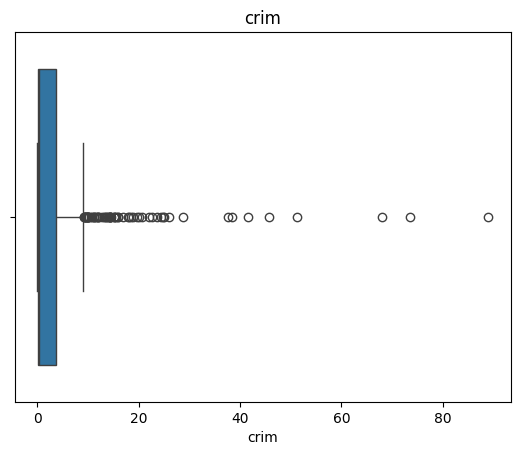

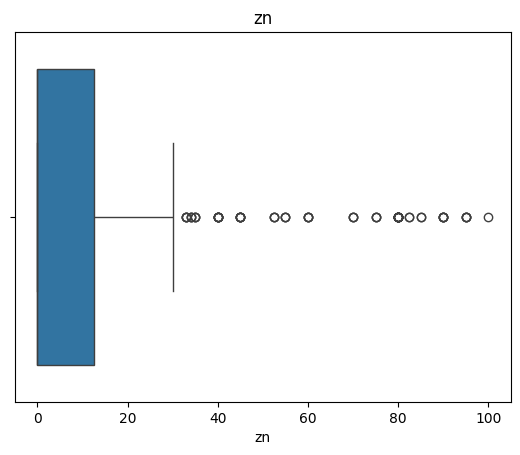

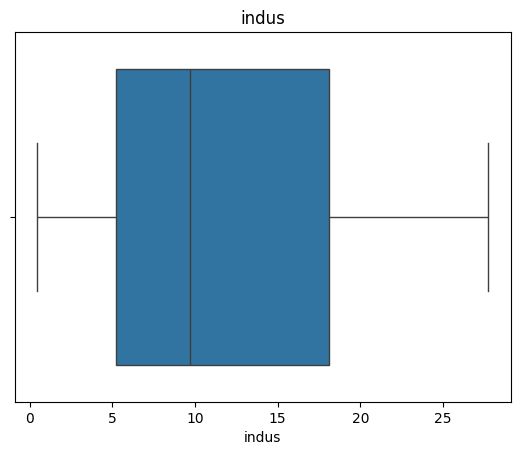

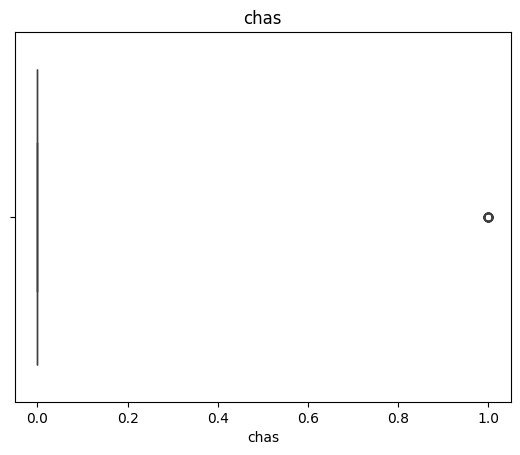

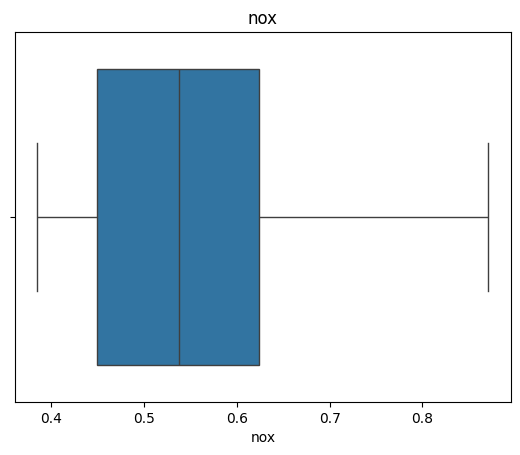

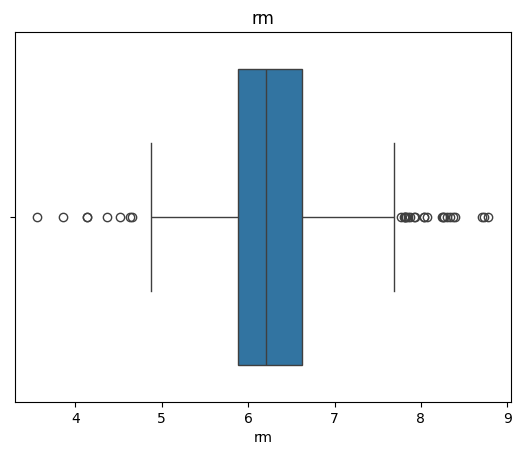

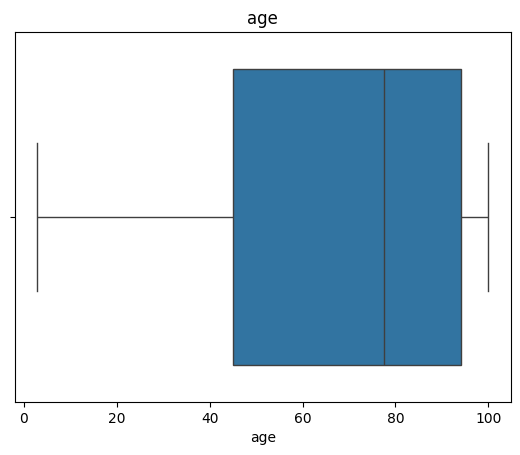

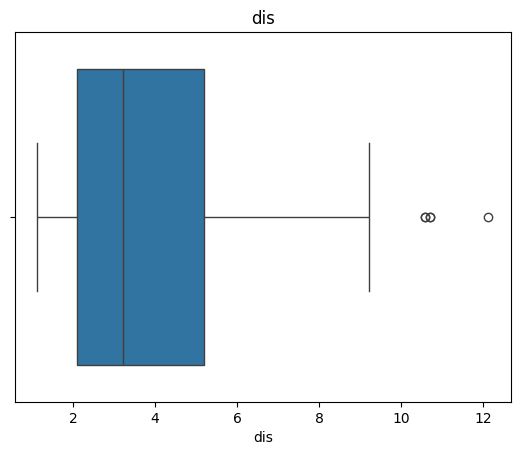

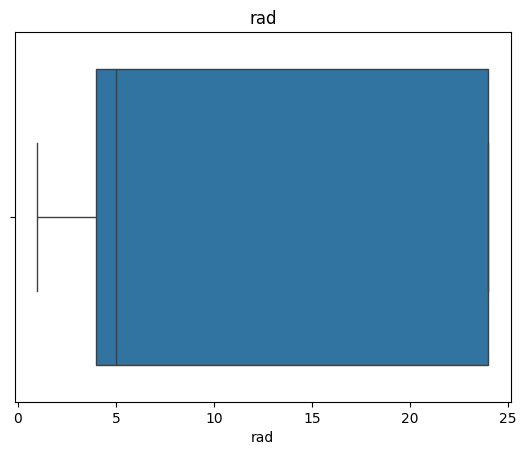

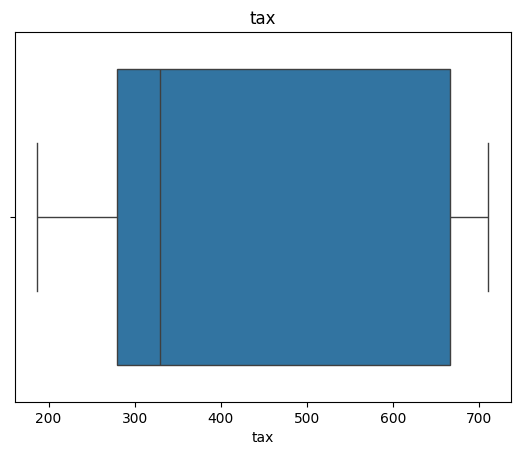

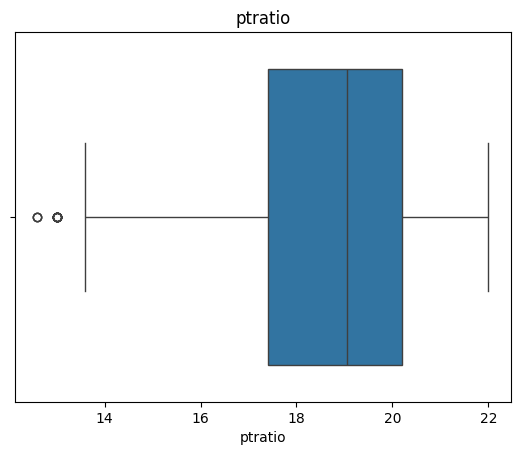

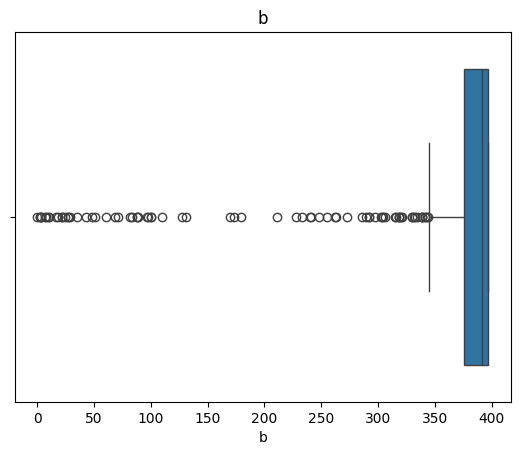

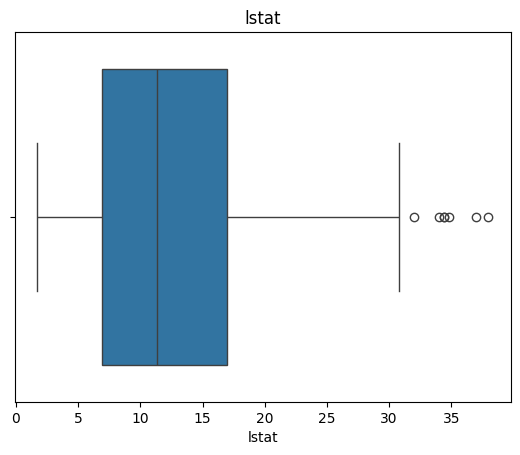

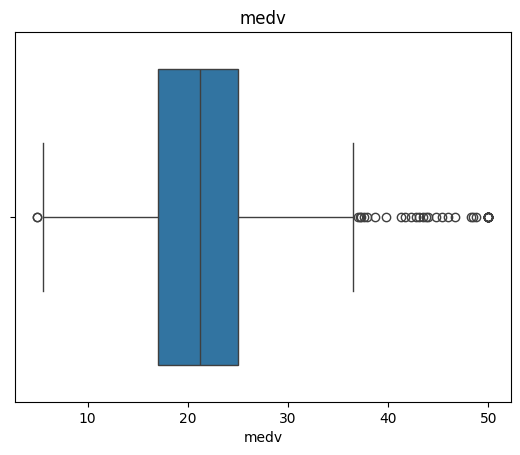

In [12]:
for i in col_list:
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

In [15]:
for i in col_list:
    if i == 'medv':
        continue
    if i == 'chas':
        continue
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier = df[(df[i] < lower) | (df[i] > upper)].index
    df = df.drop(outlier)
    

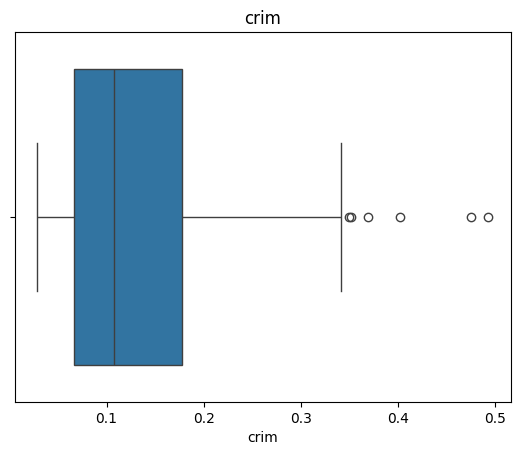

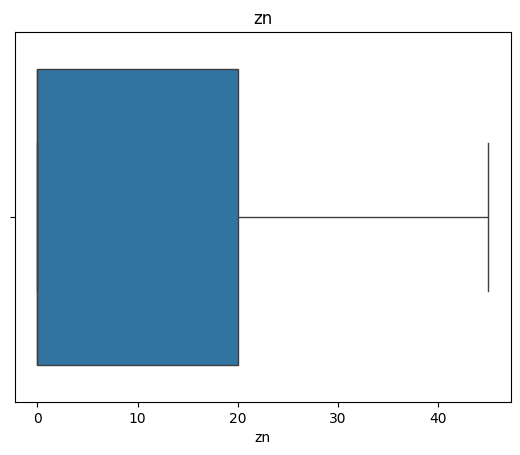

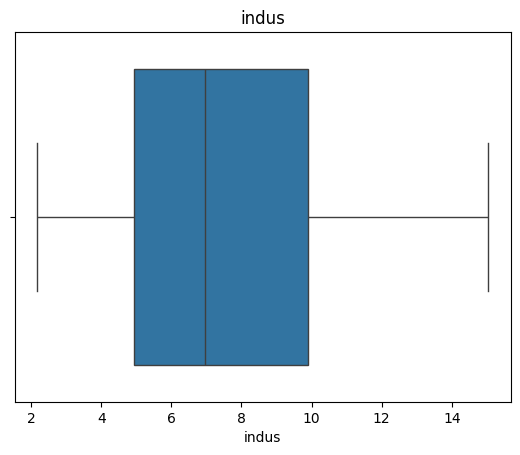

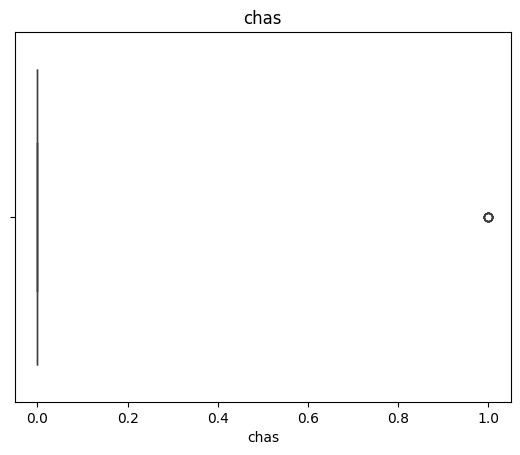

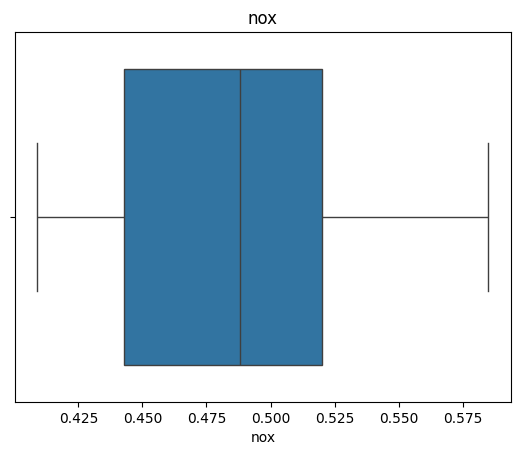

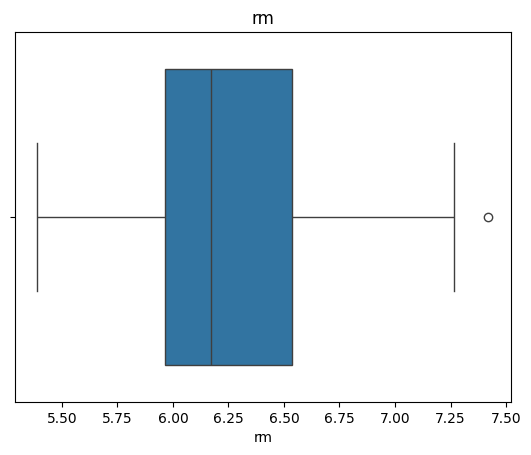

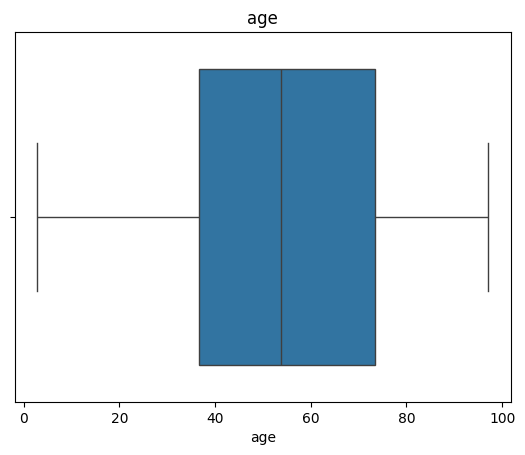

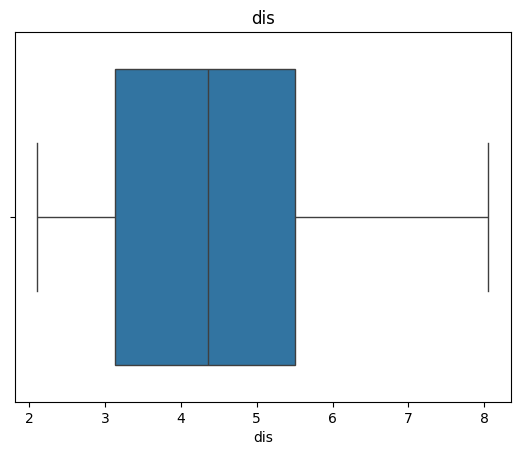

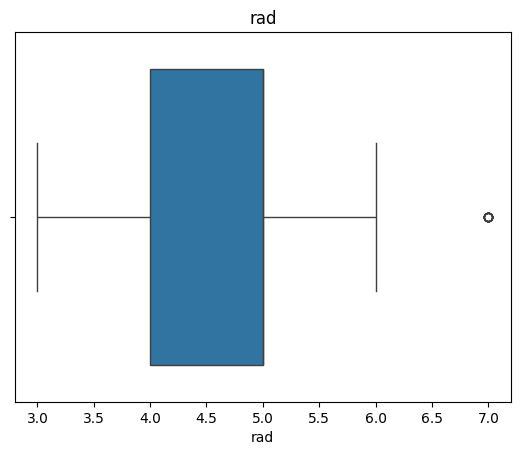

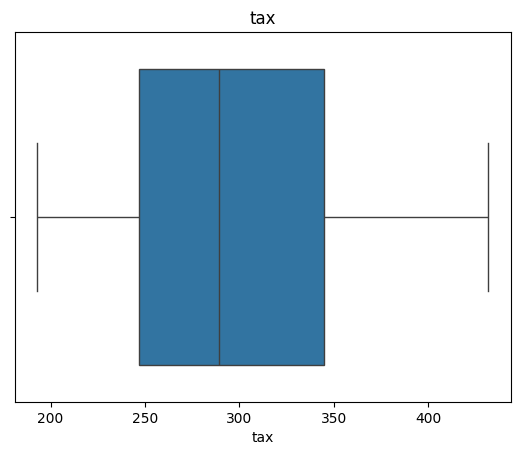

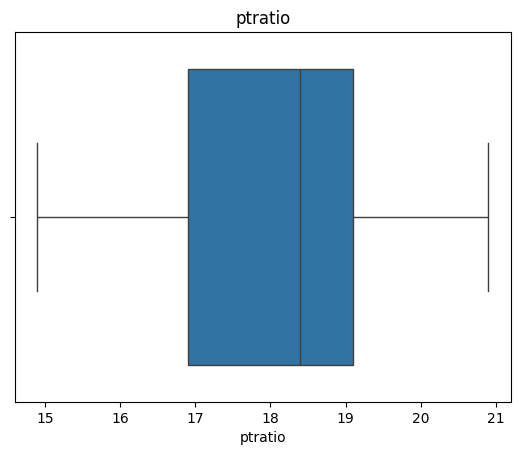

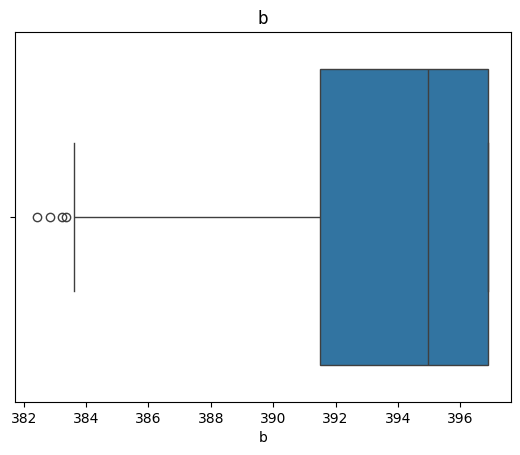

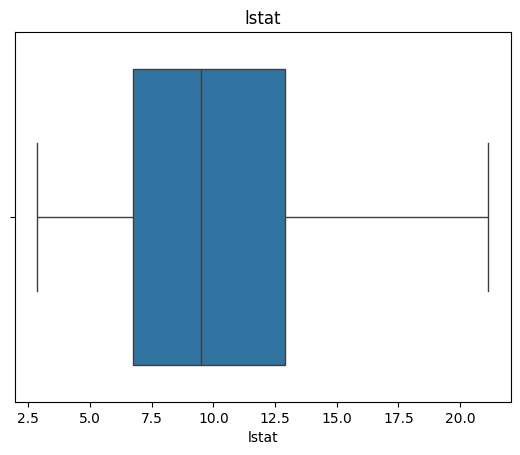

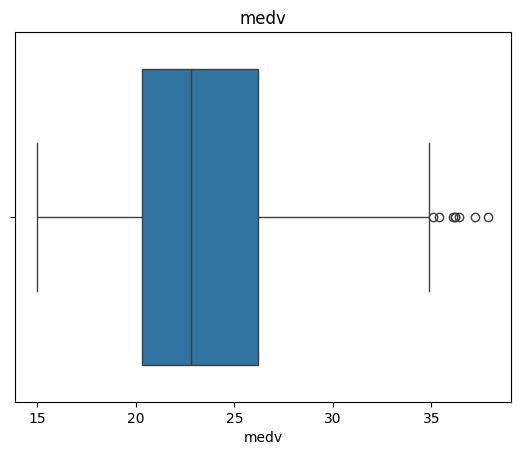

In [16]:
for i in col_list:
    sns.boxplot(x=df[i])
    plt.title(i)
    plt.show()

## Conclusion
### Data seems to well cleaned and proccesed

# Exploratory Data Analysis

## Univarite analysis

<Figure size 640x480 with 0 Axes>

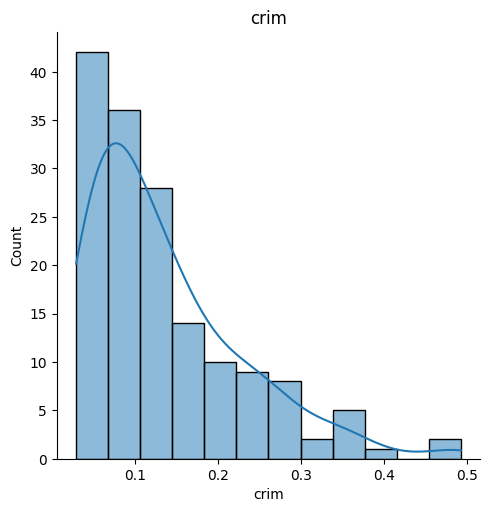

<Figure size 640x480 with 0 Axes>

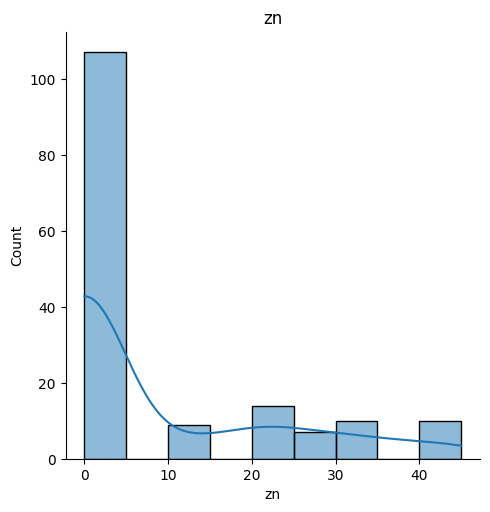

<Figure size 640x480 with 0 Axes>

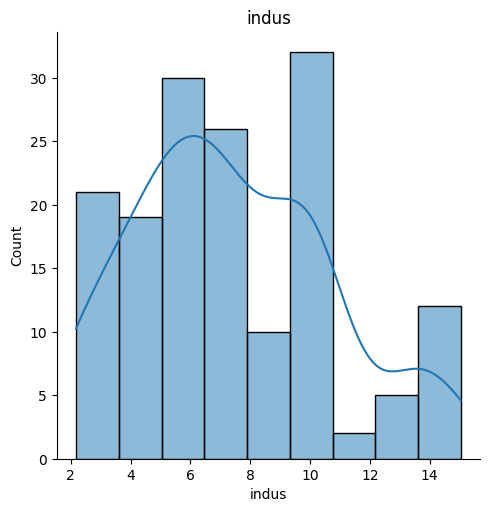

<Figure size 640x480 with 0 Axes>

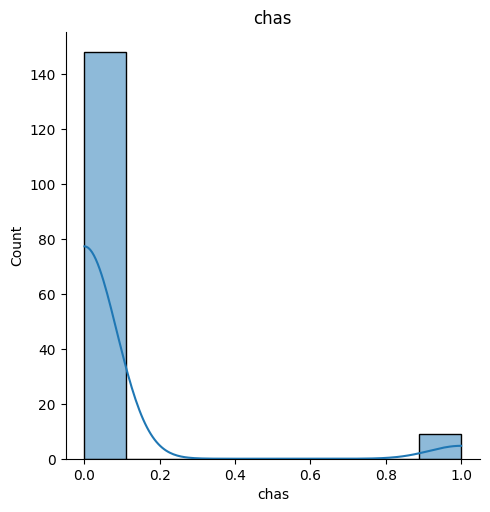

<Figure size 640x480 with 0 Axes>

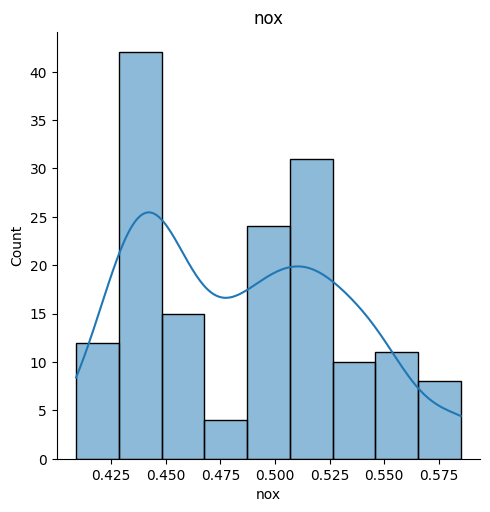

<Figure size 640x480 with 0 Axes>

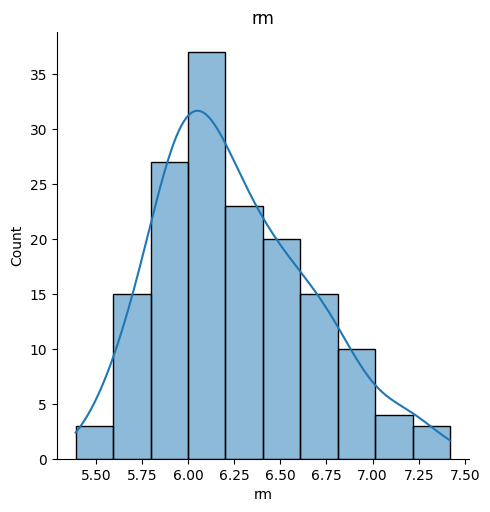

<Figure size 640x480 with 0 Axes>

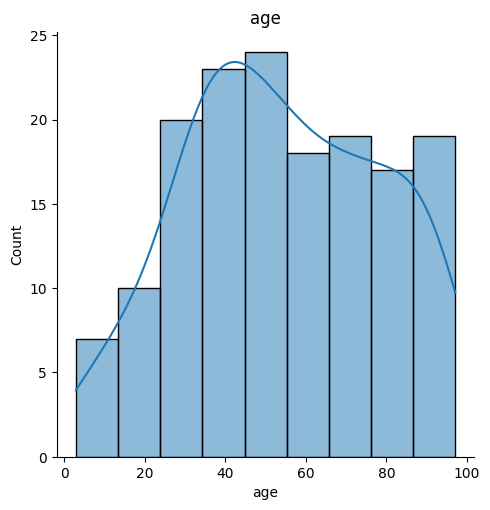

<Figure size 640x480 with 0 Axes>

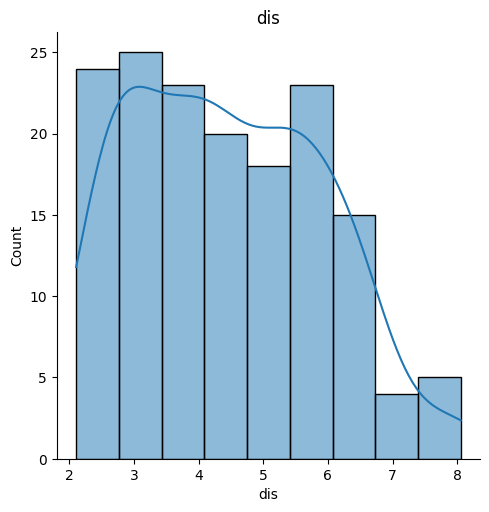

<Figure size 640x480 with 0 Axes>

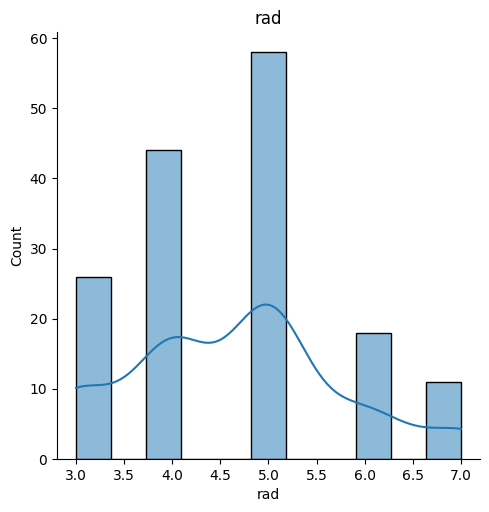

<Figure size 640x480 with 0 Axes>

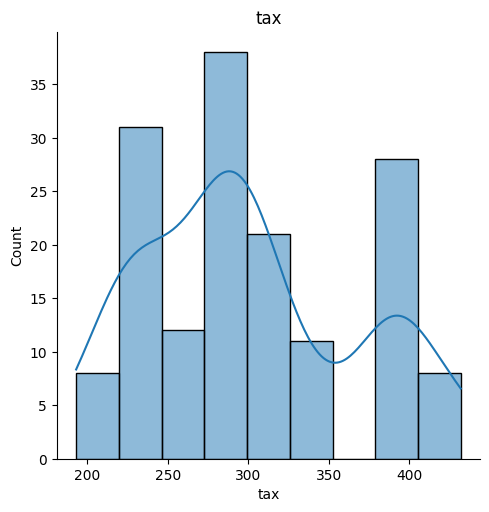

<Figure size 640x480 with 0 Axes>

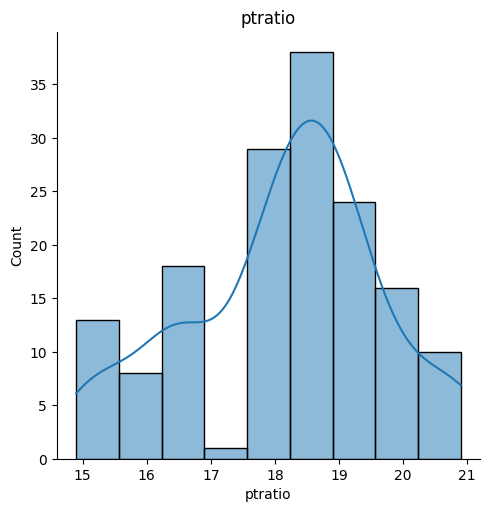

<Figure size 640x480 with 0 Axes>

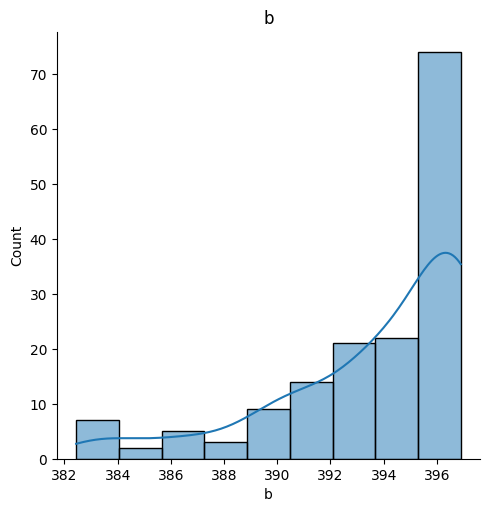

<Figure size 640x480 with 0 Axes>

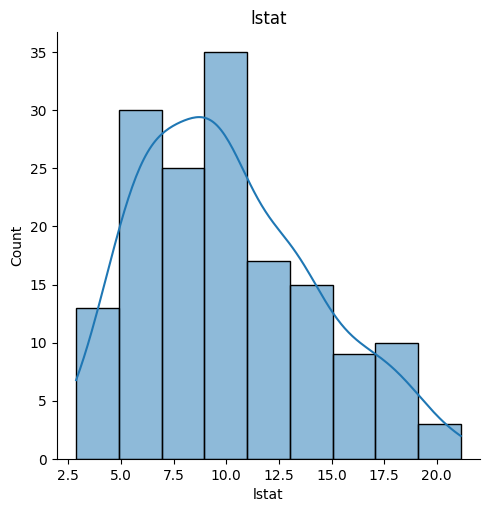

<Figure size 640x480 with 0 Axes>

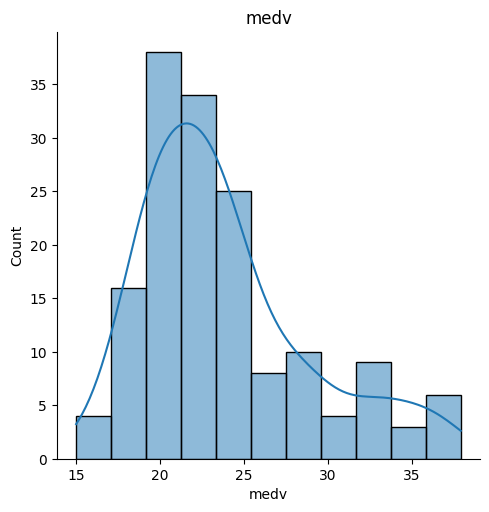

In [17]:
for i in col_list:
    plt.figure()
    sns.displot(data=df[i], kde=True)
    plt.title(f'{i}')
    plt.show()

## Bivarite Analysis

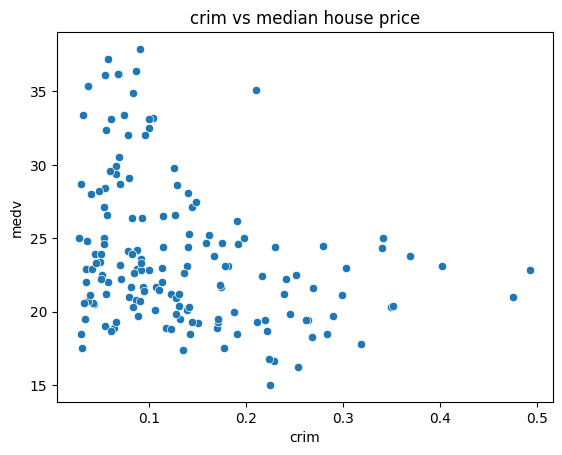

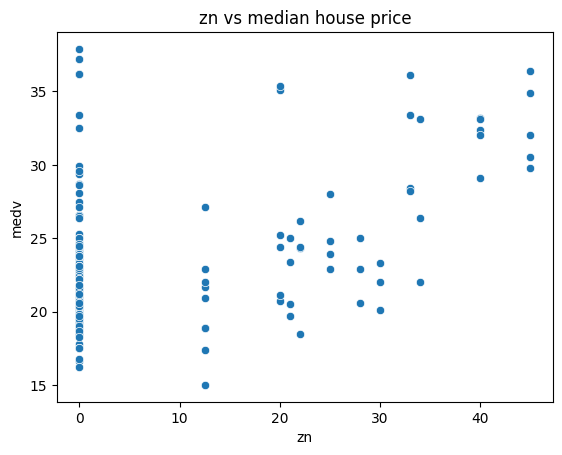

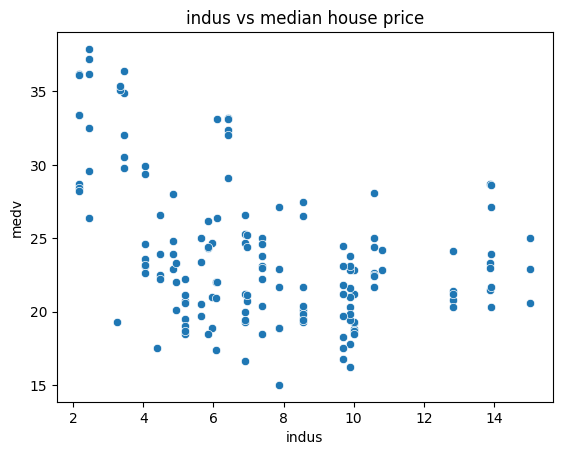

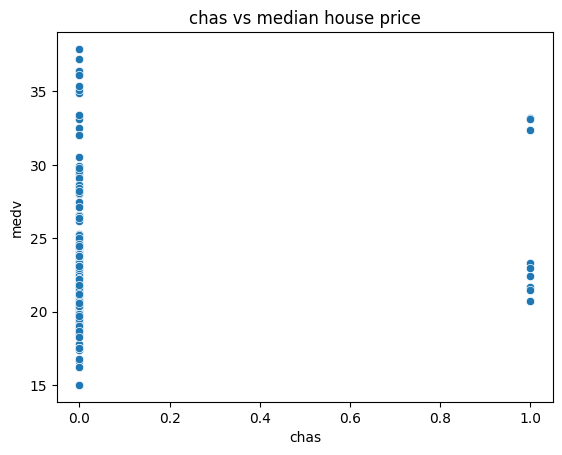

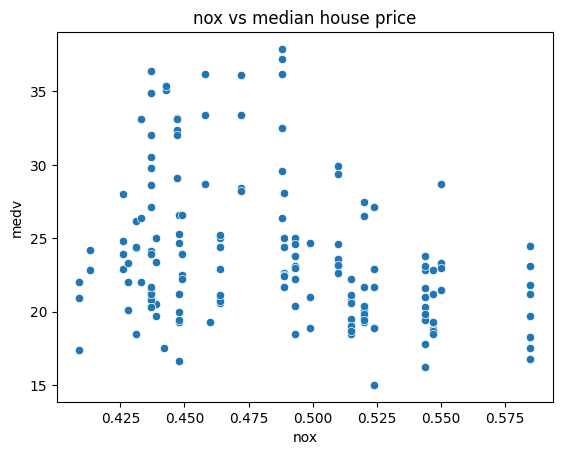

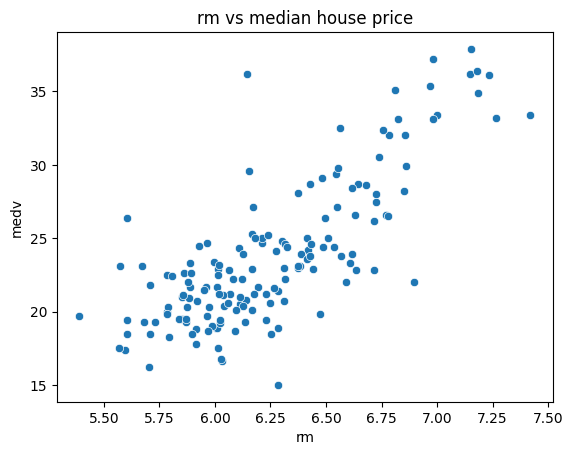

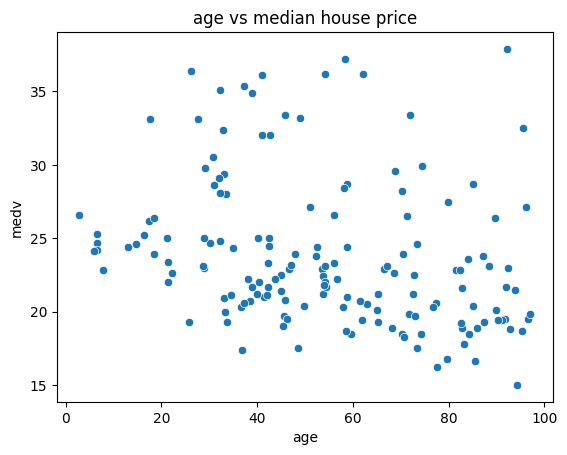

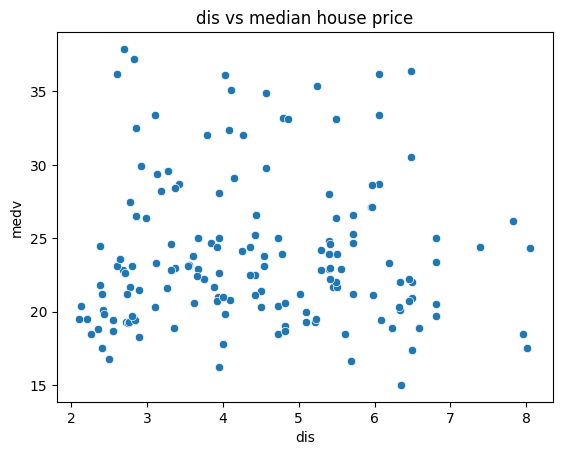

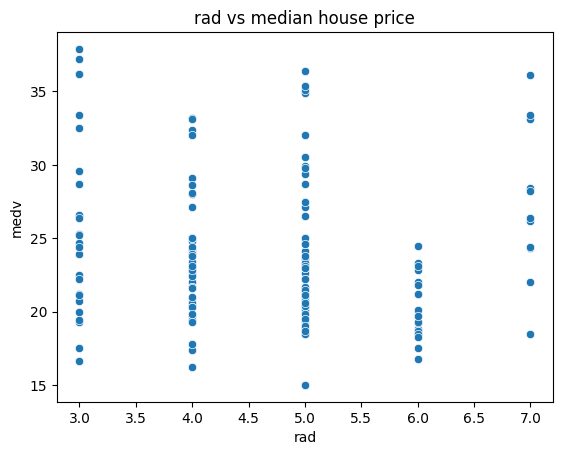

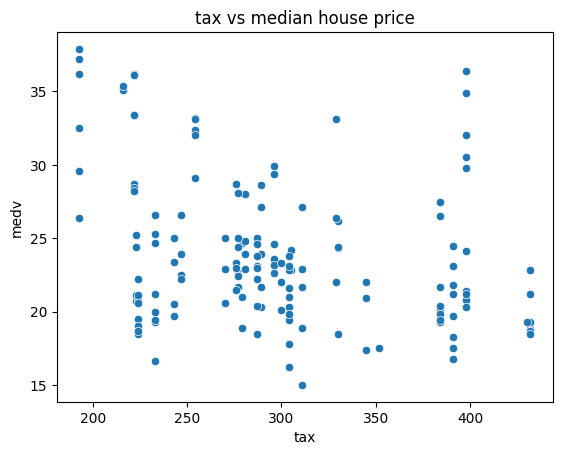

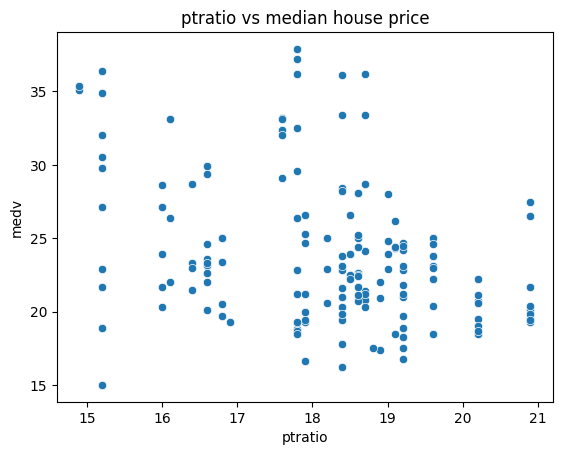

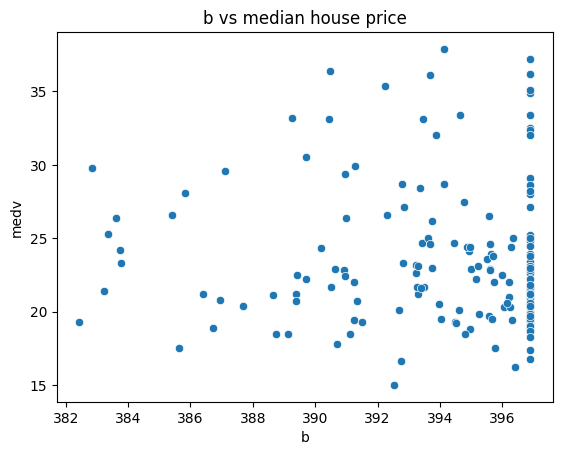

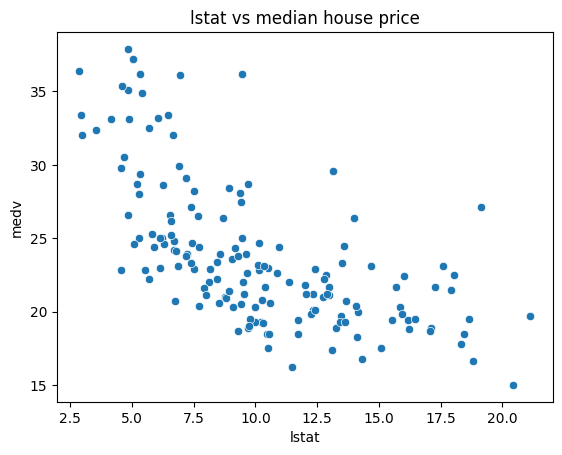

In [18]:
for i in col_list:
    if i != 'medv':
        plt.figure()
        sns.scatterplot(data=df, x= i, y= 'medv')
        plt.title(f'{i} vs median house price')
        plt.show()

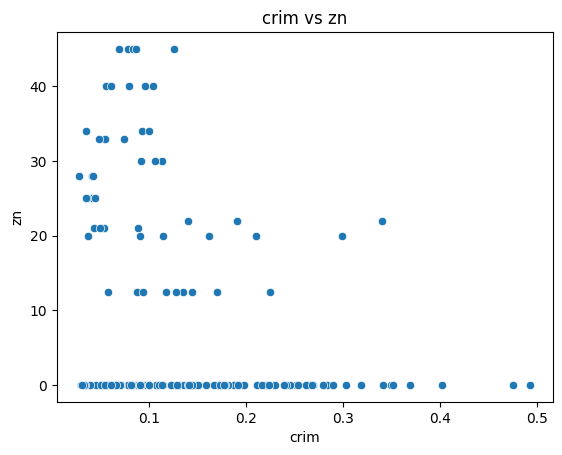

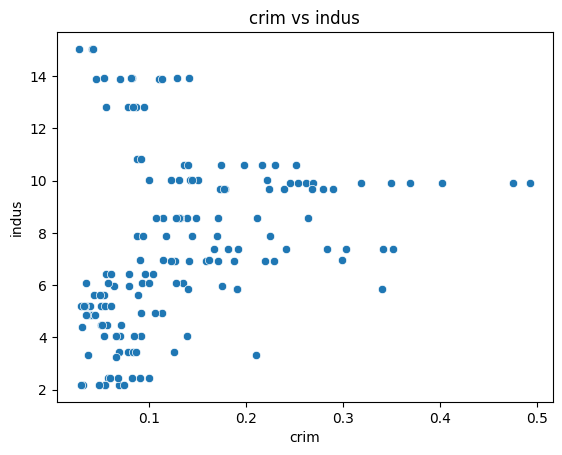

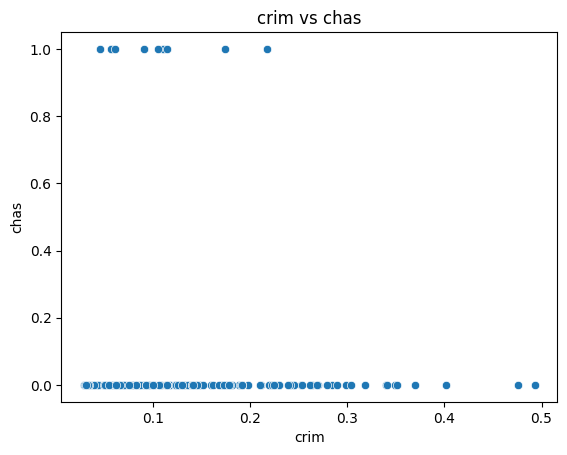

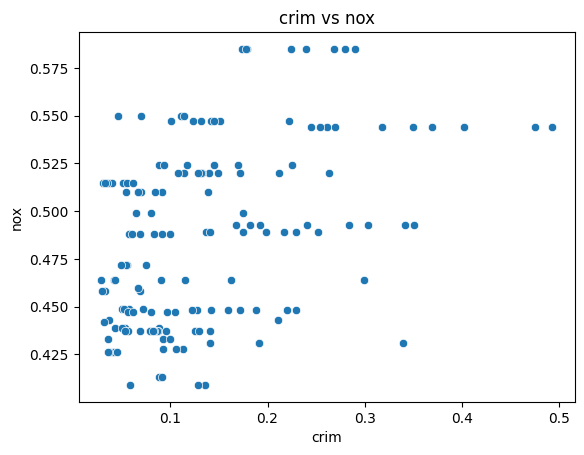

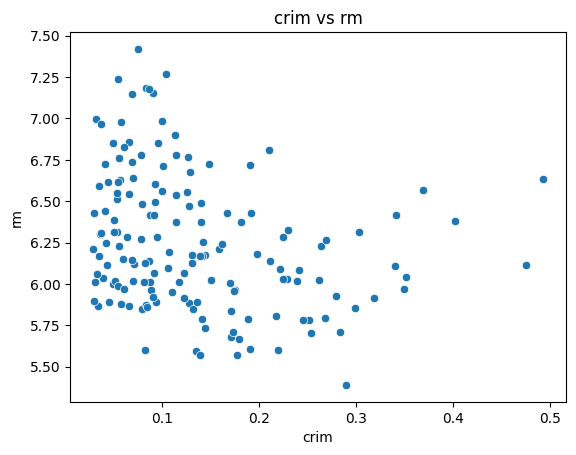

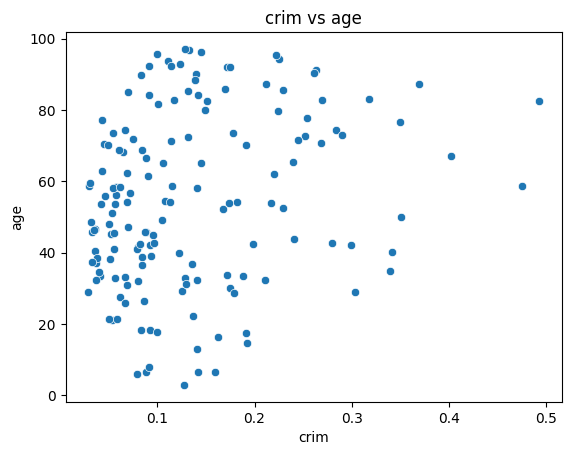

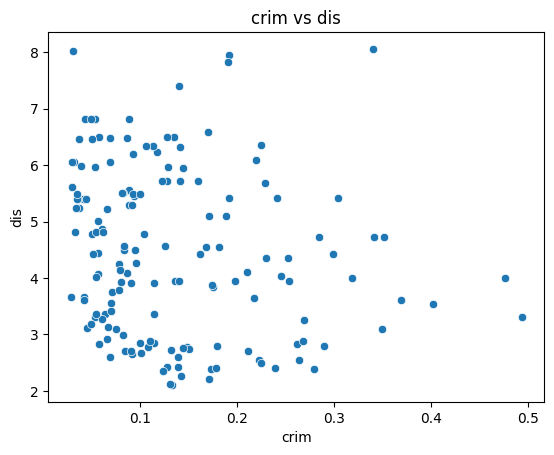

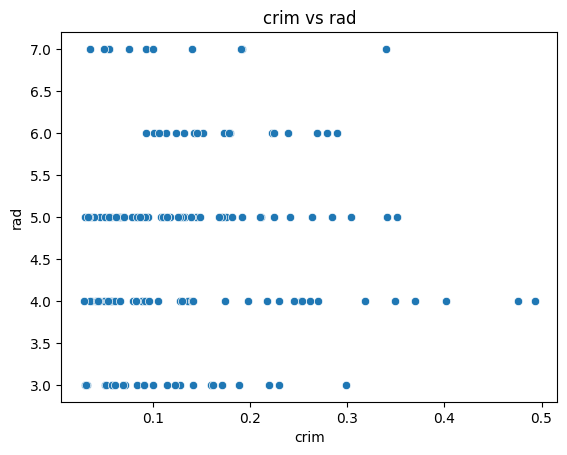

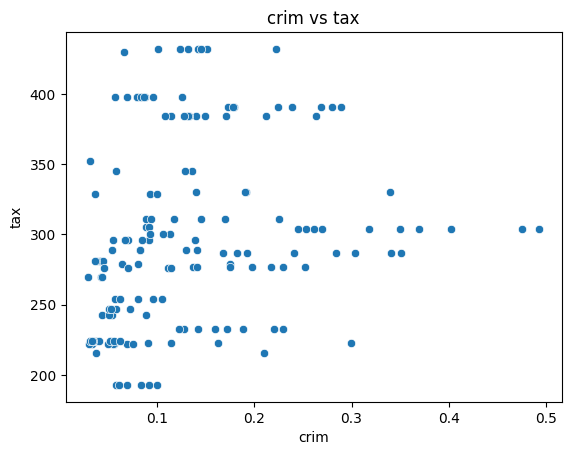

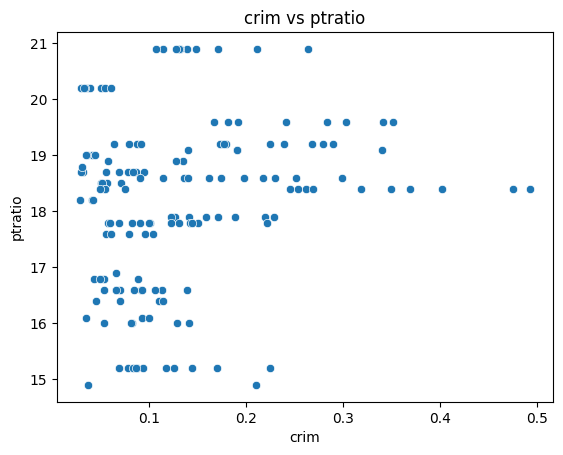

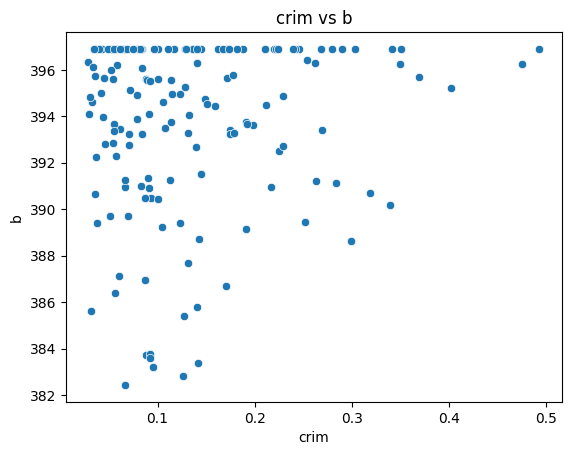

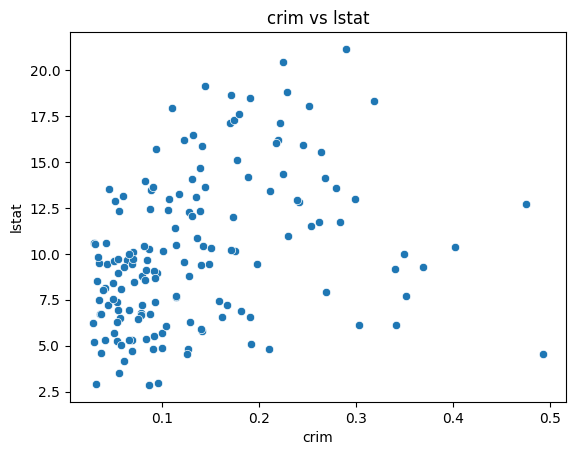

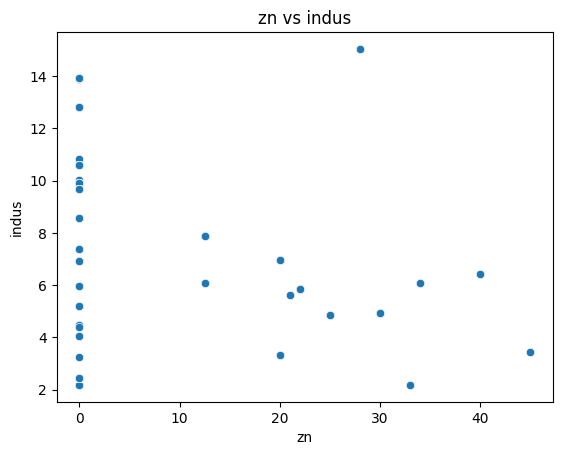

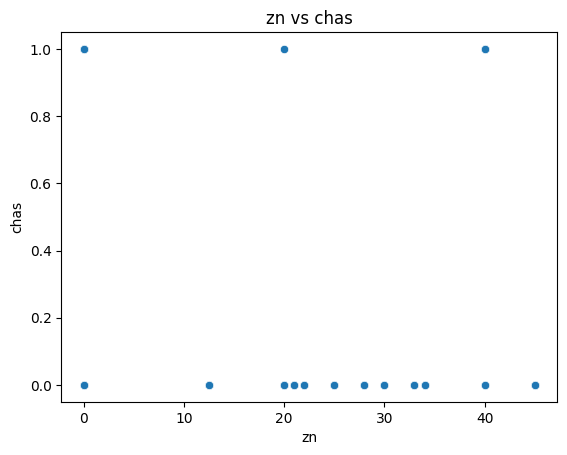

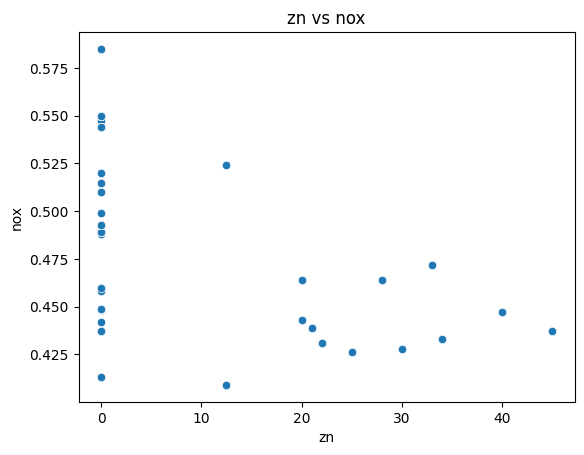

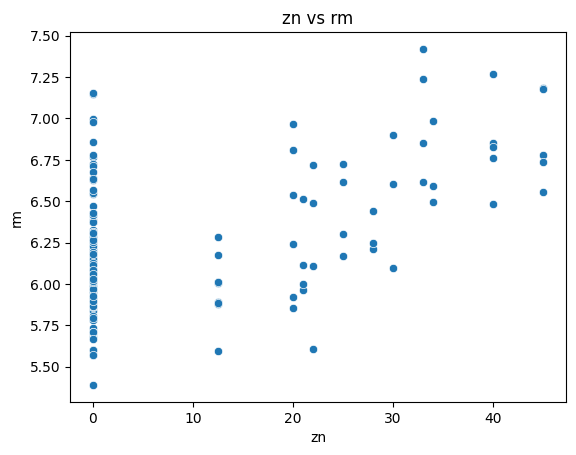

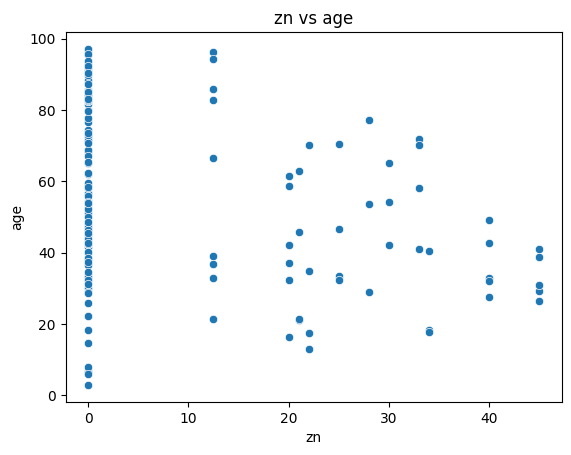

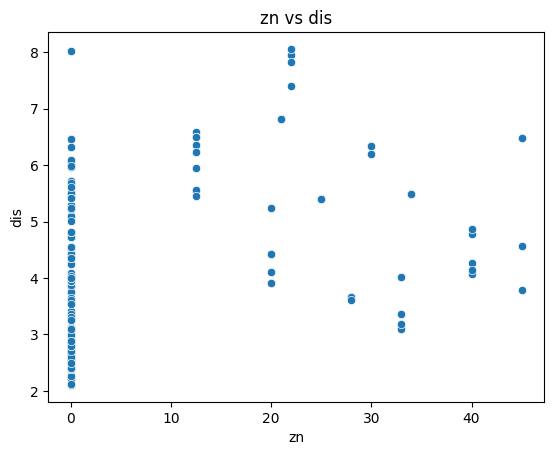

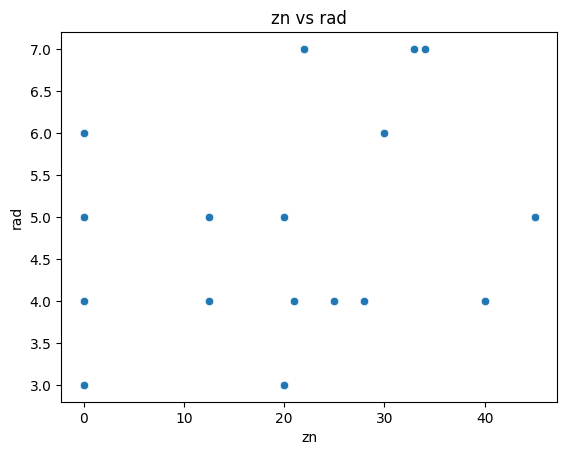

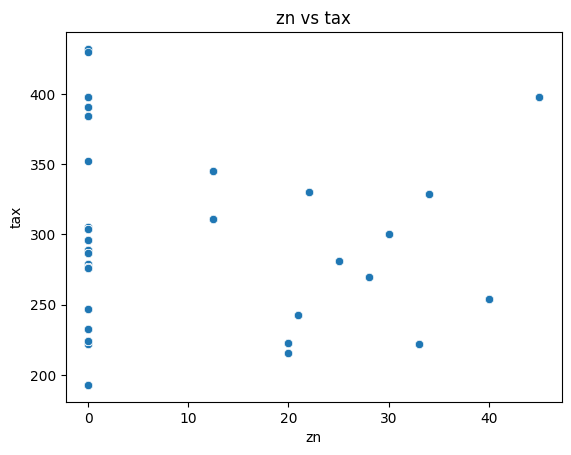

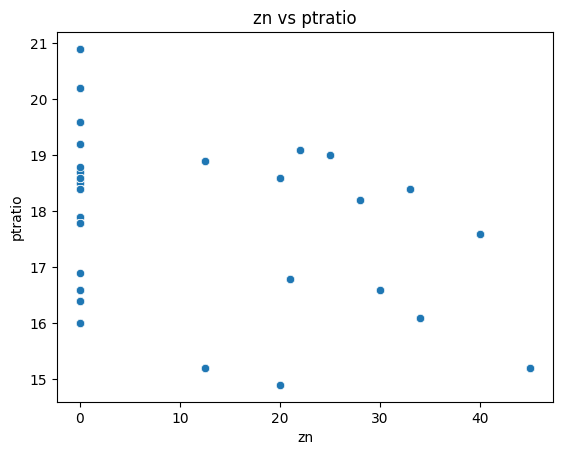

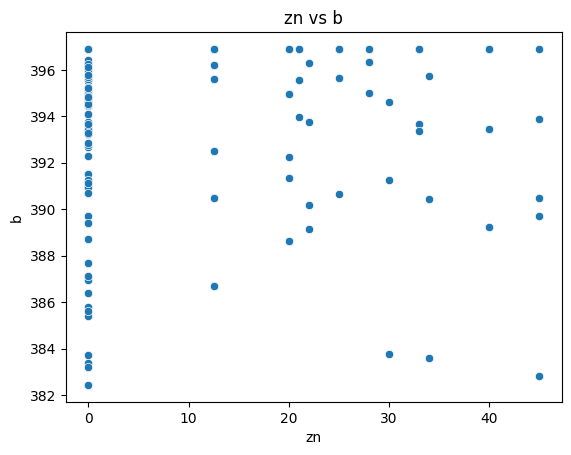

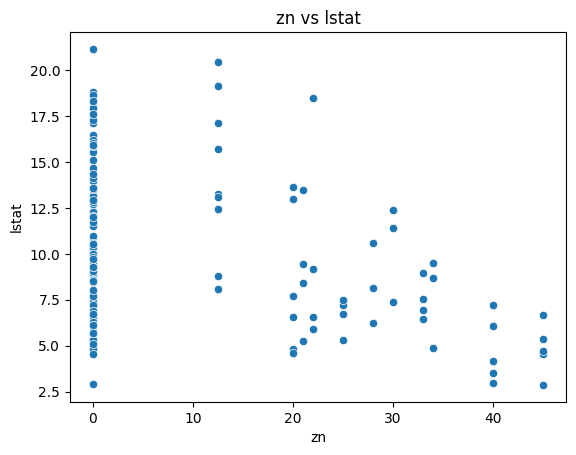

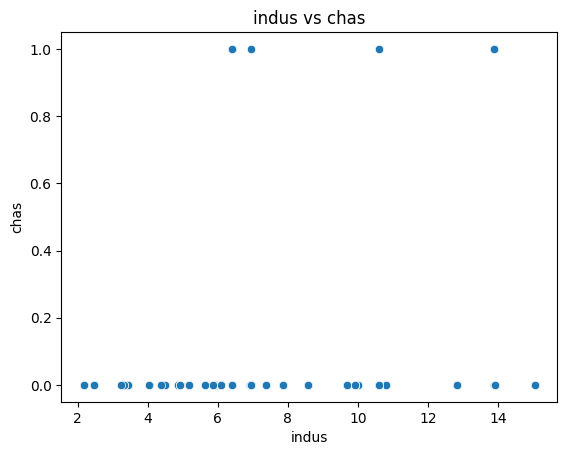

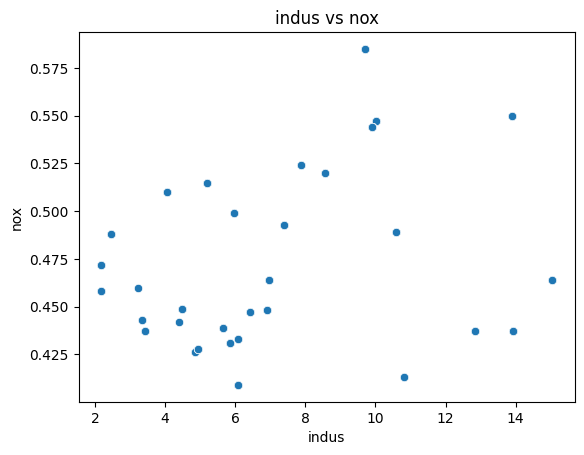

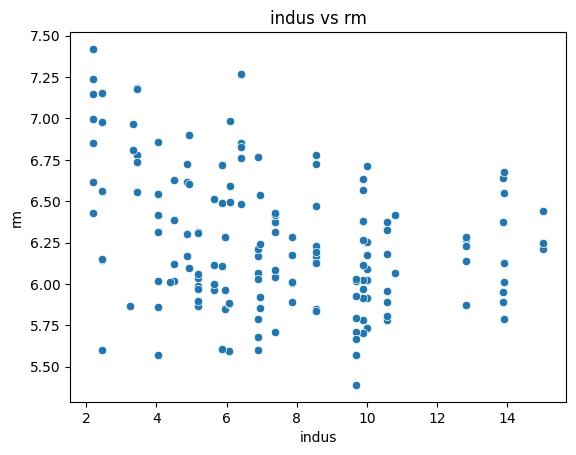

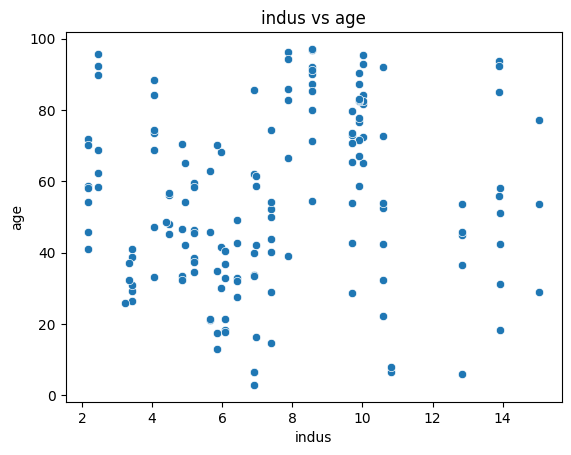

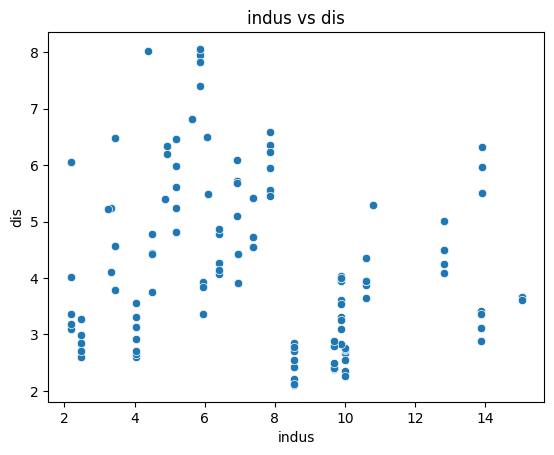

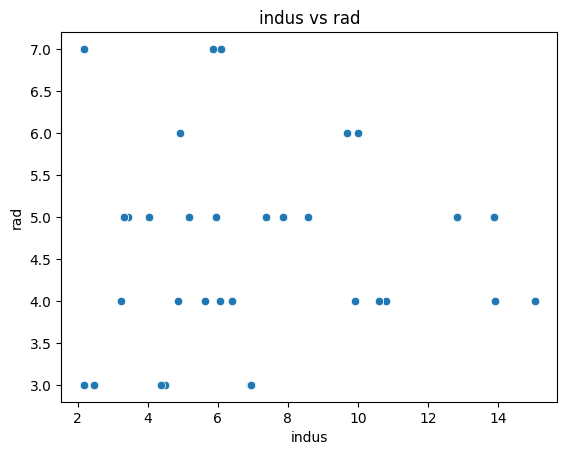

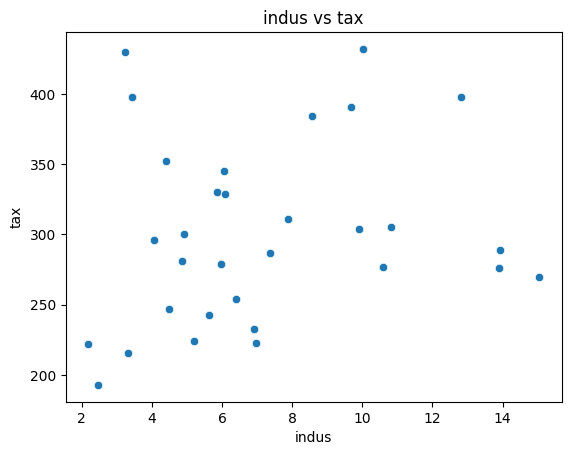

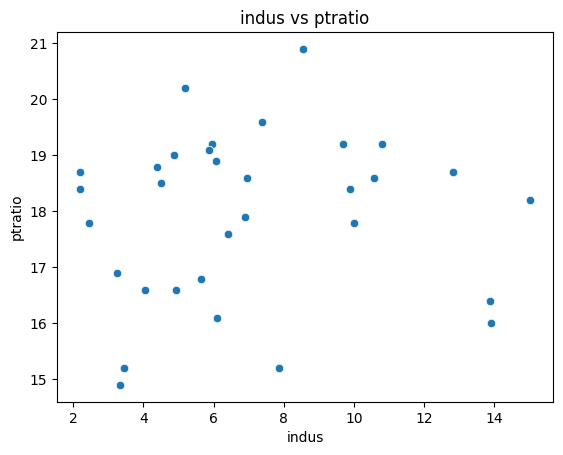

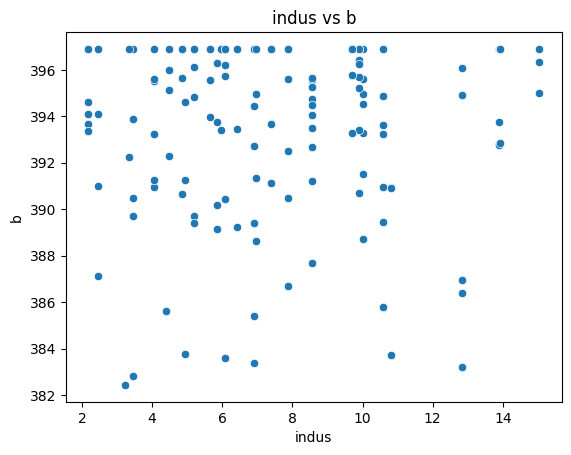

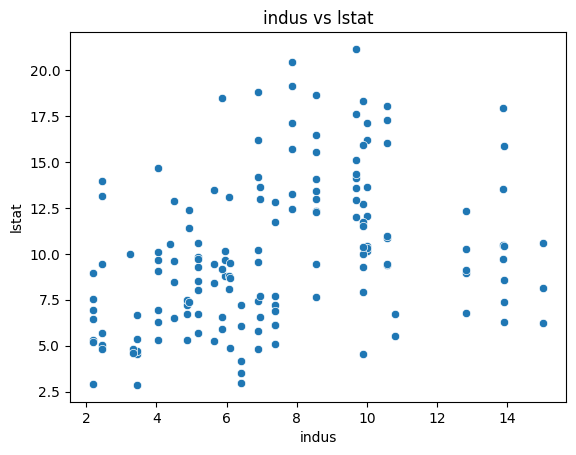

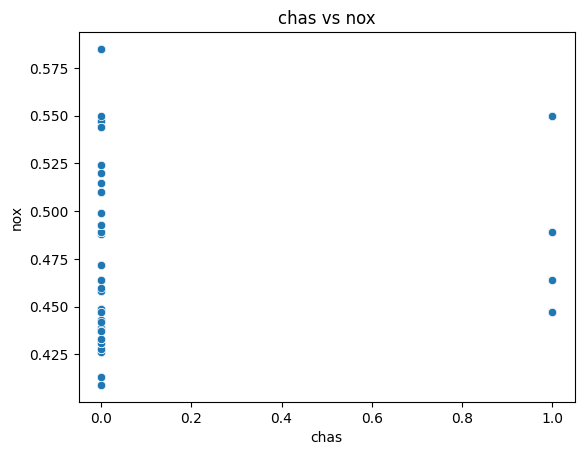

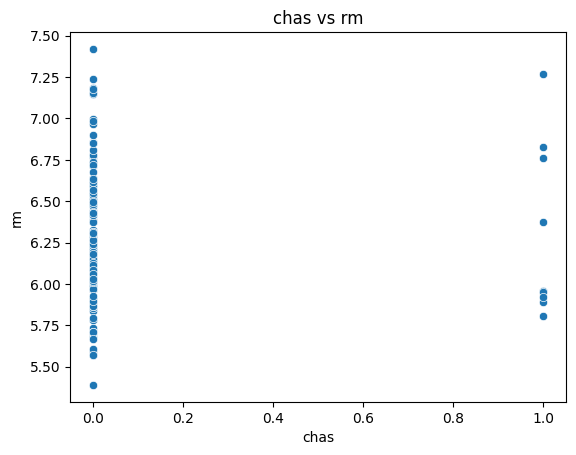

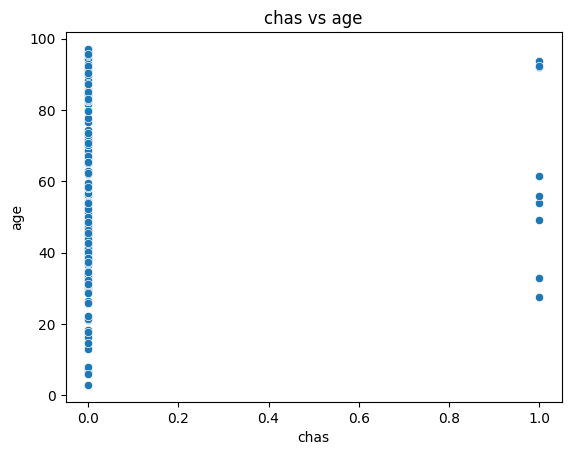

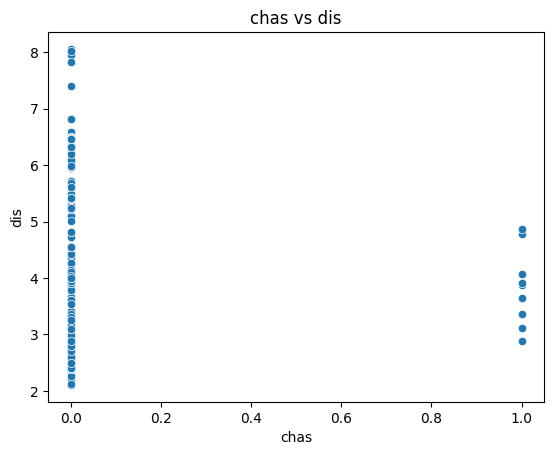

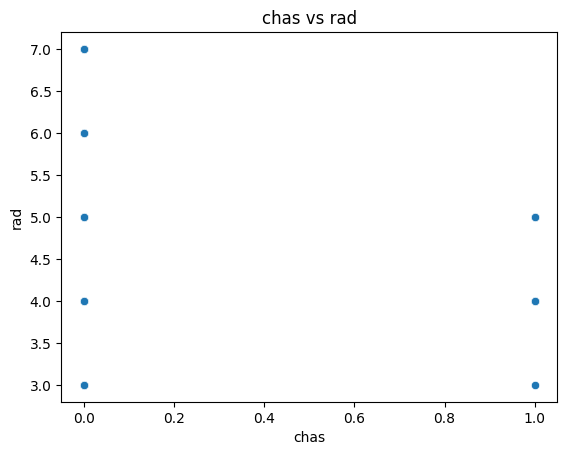

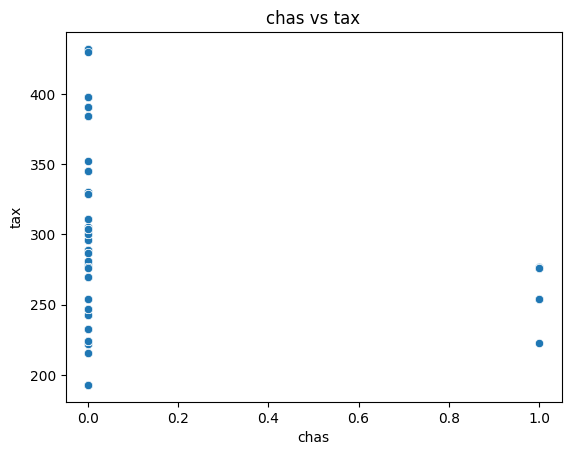

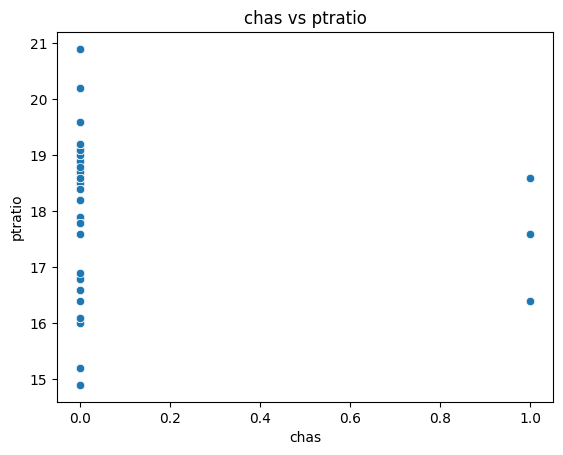

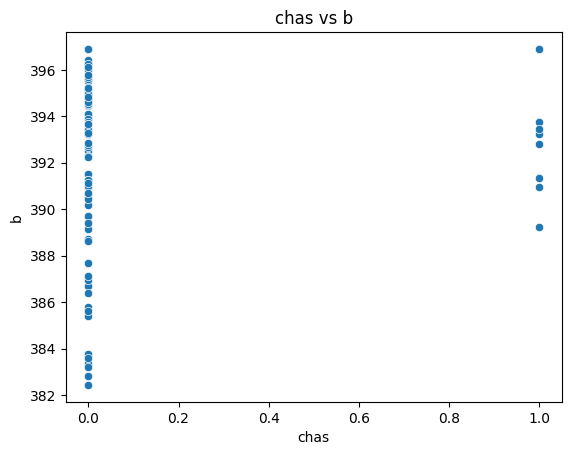

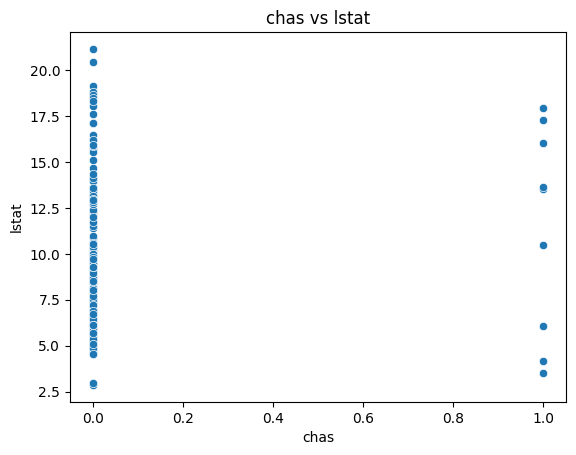

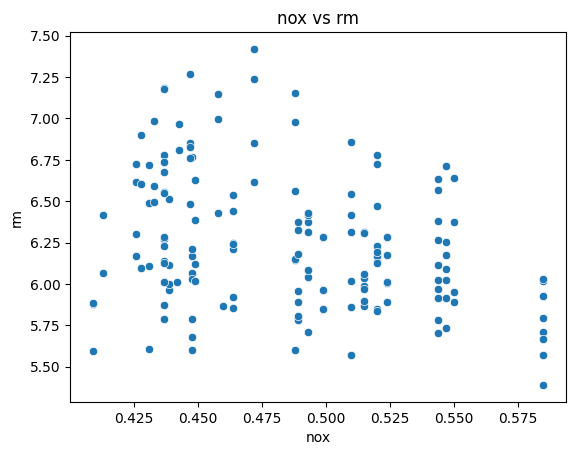

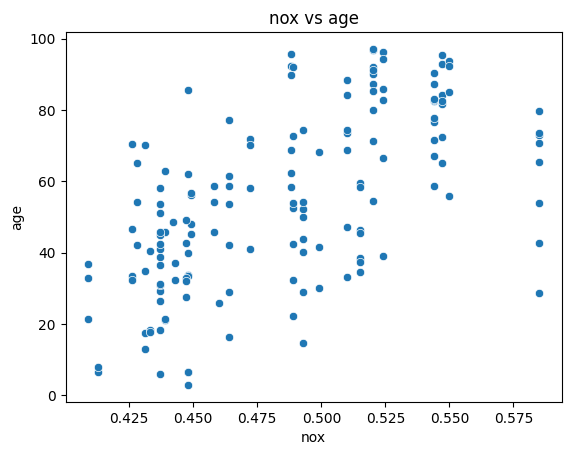

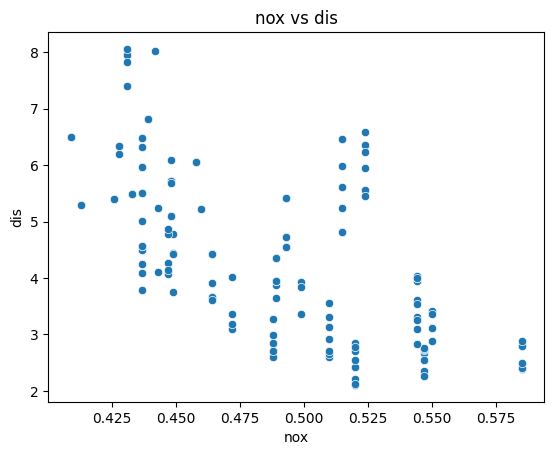

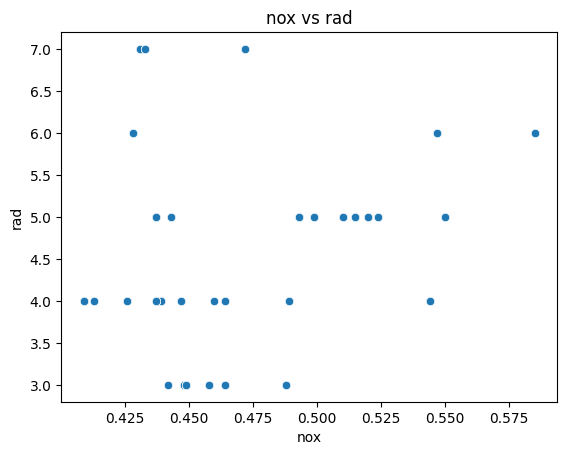

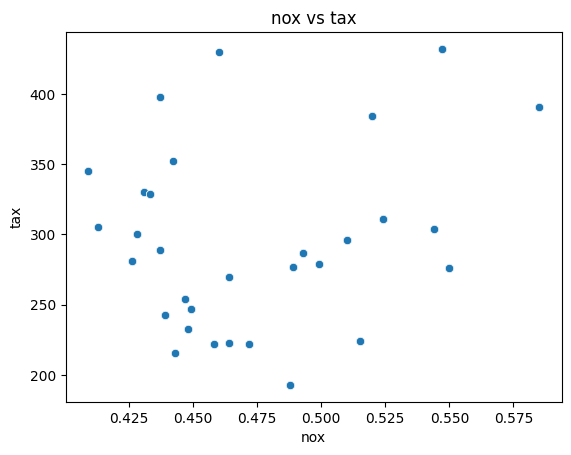

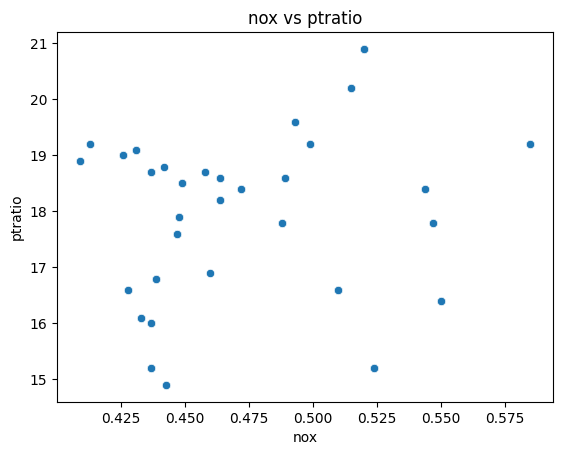

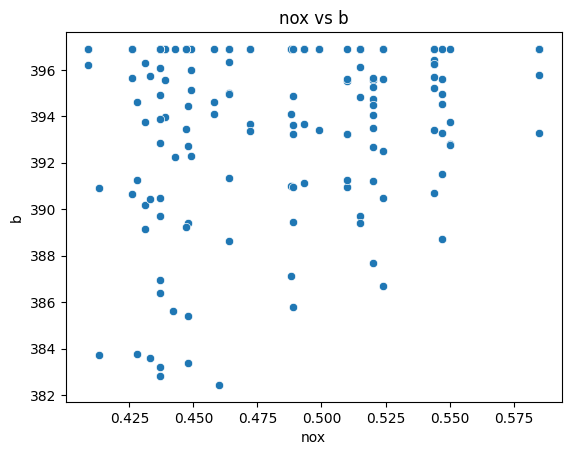

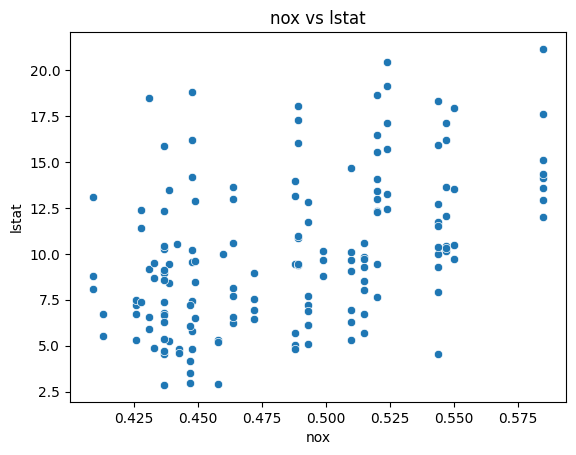

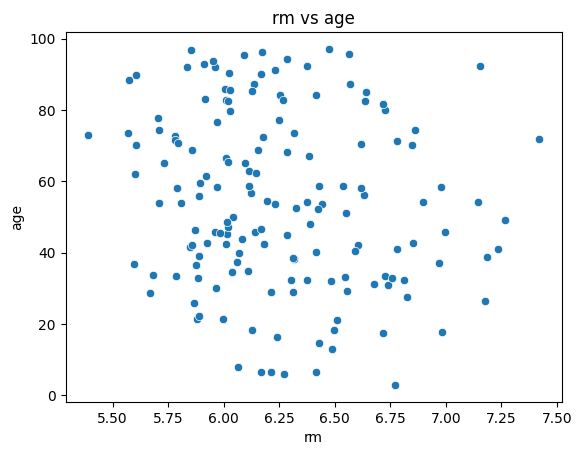

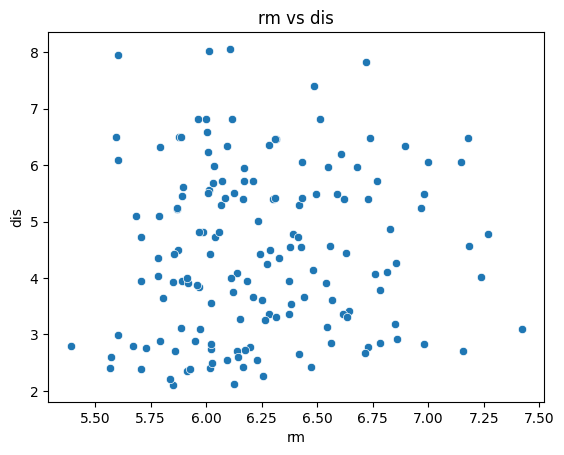

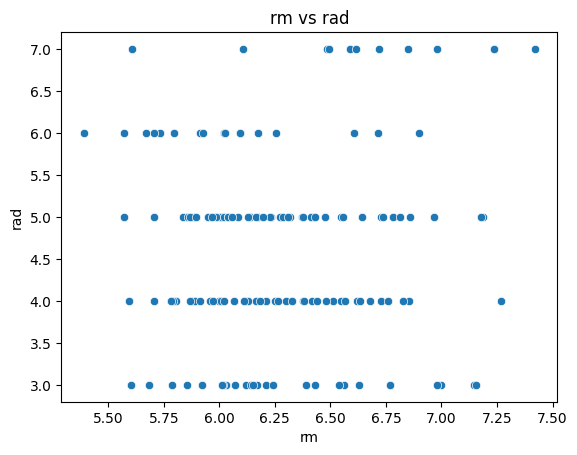

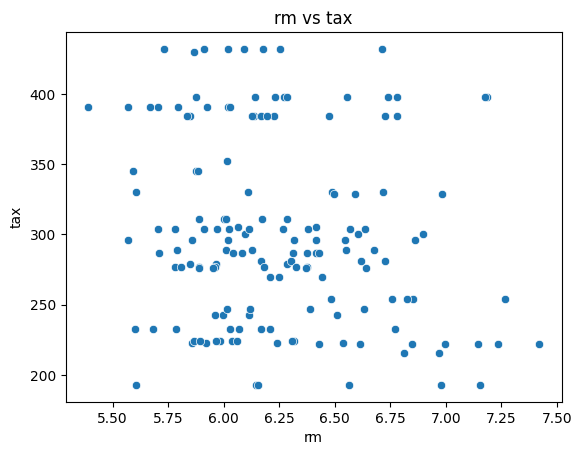

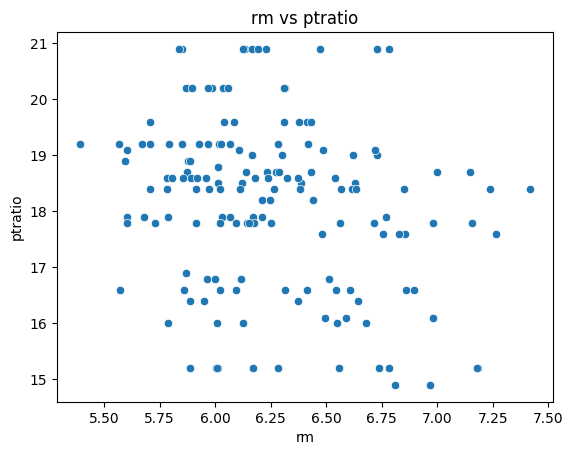

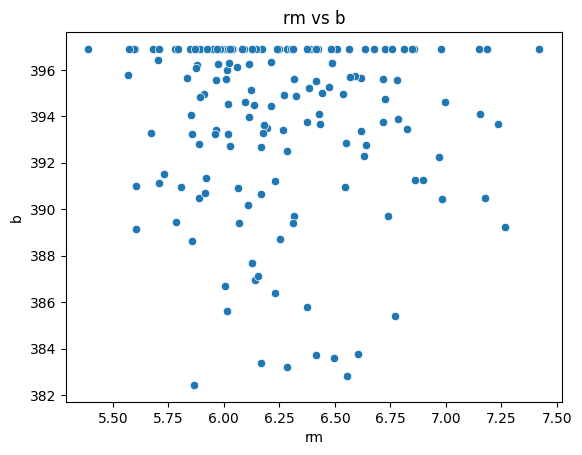

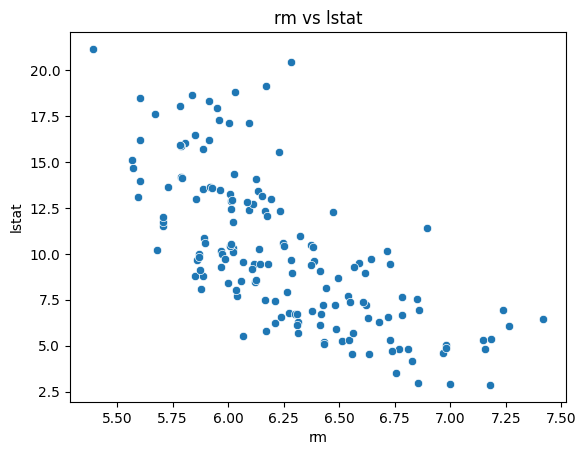

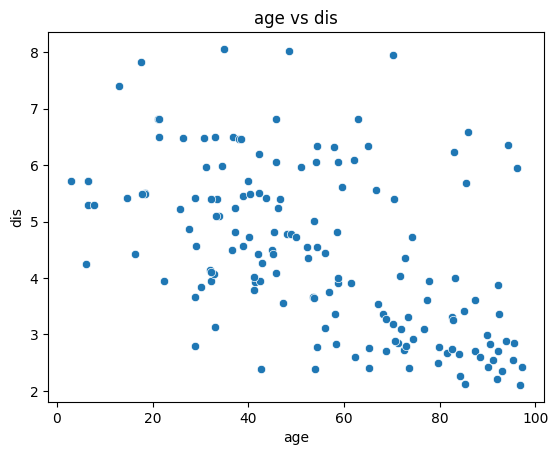

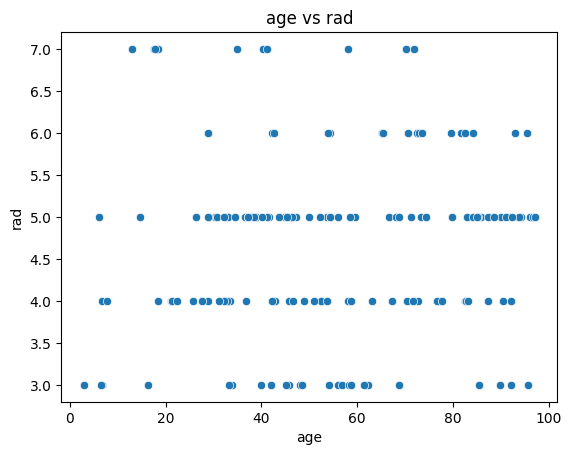

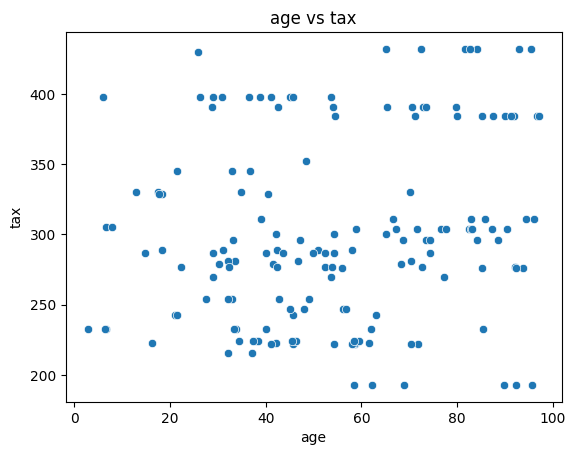

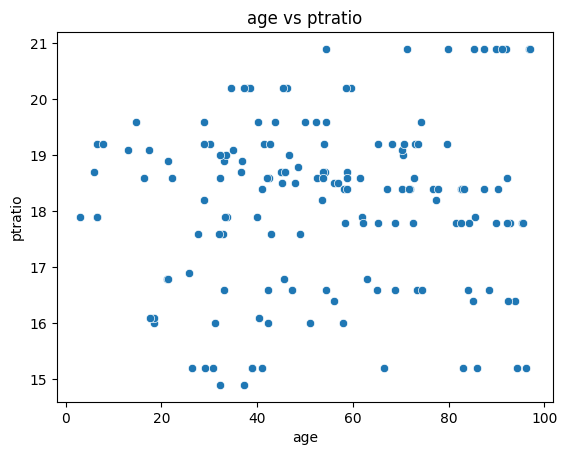

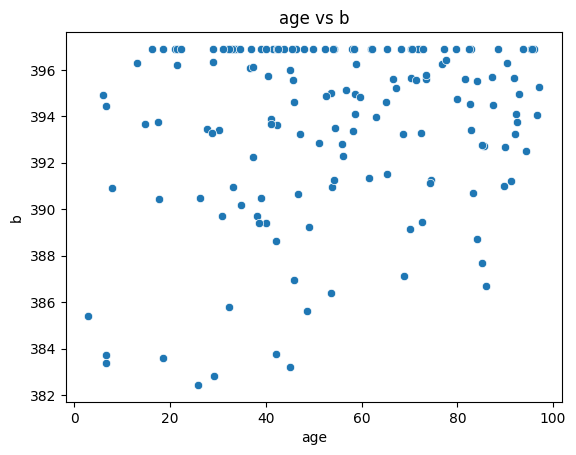

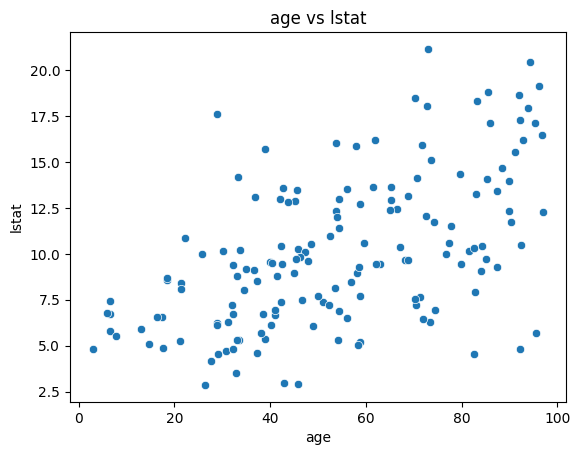

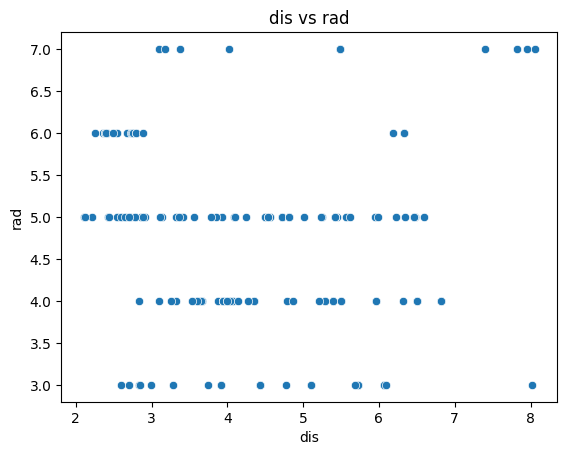

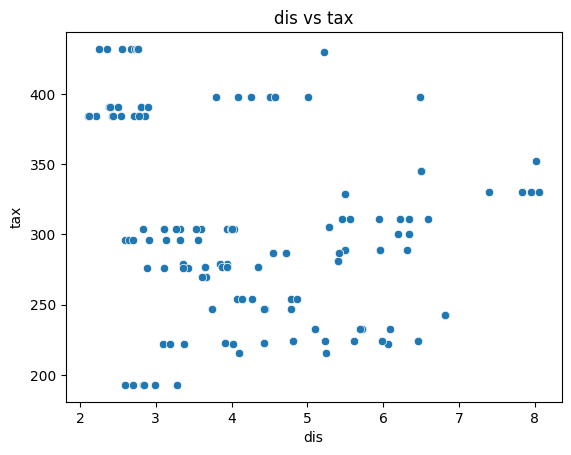

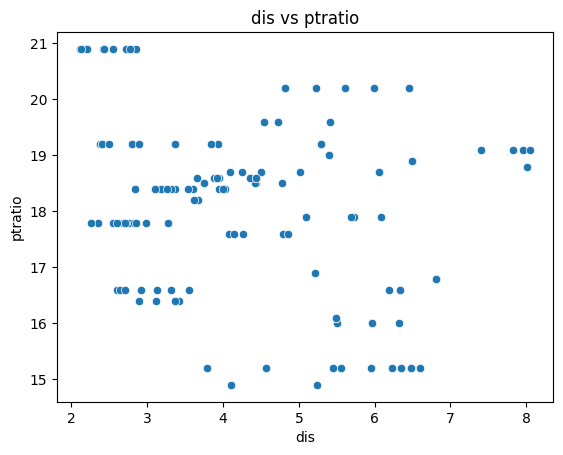

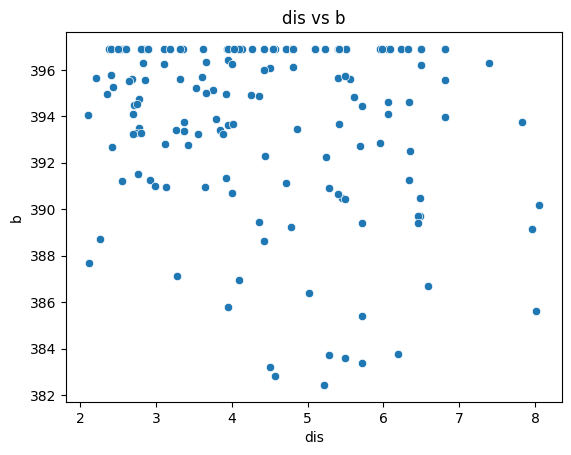

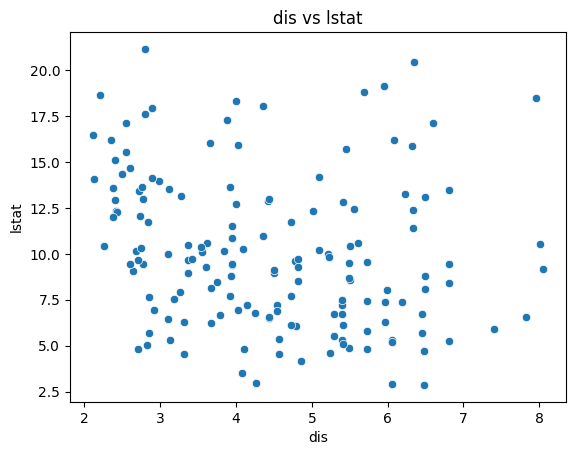

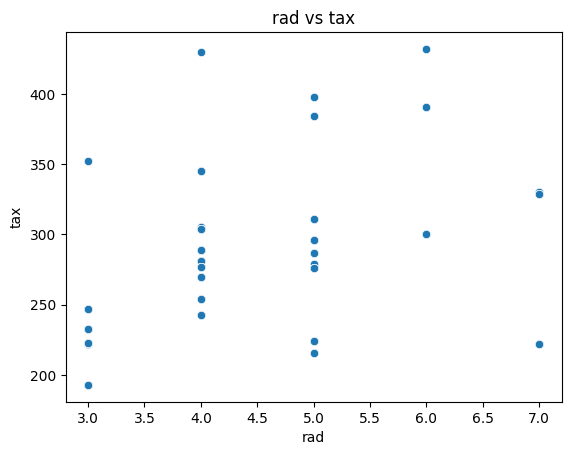

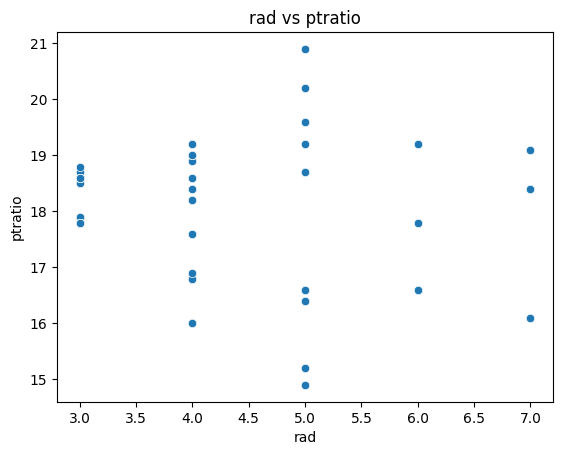

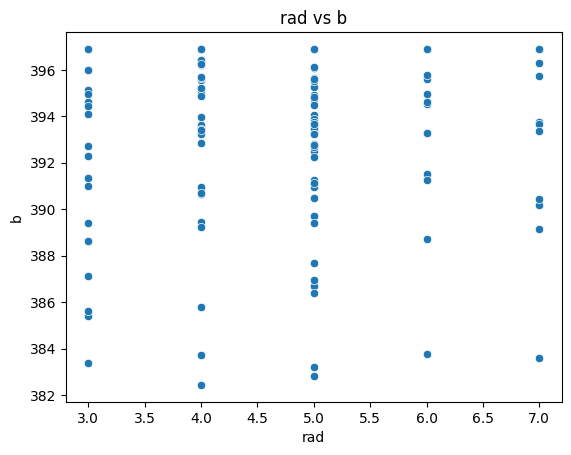

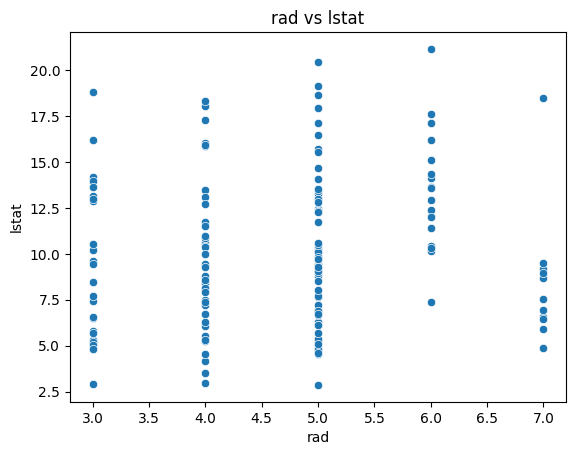

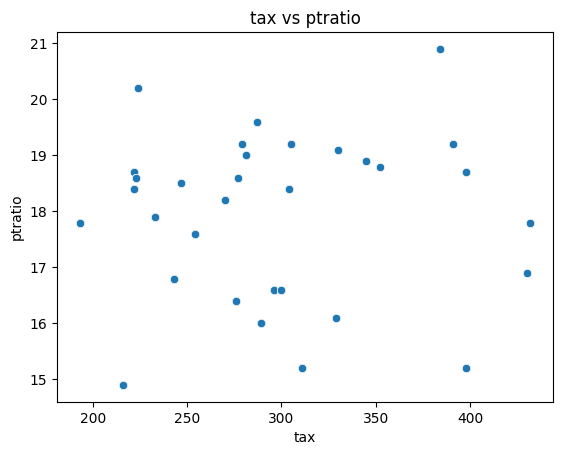

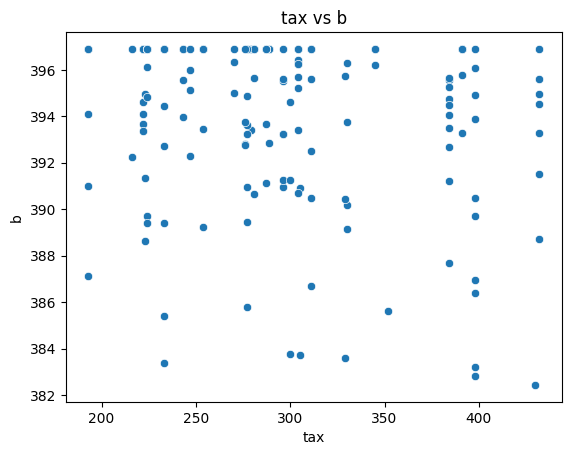

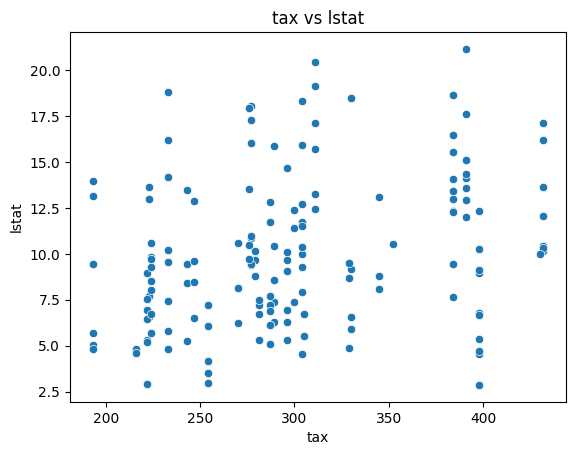

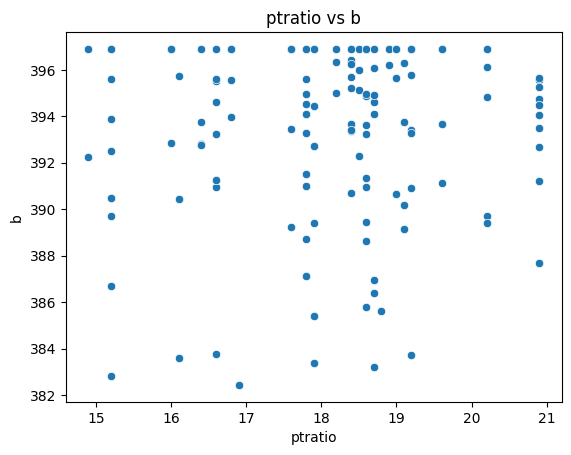

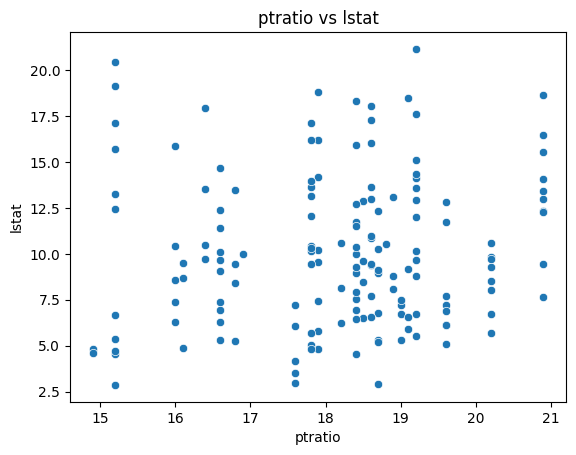

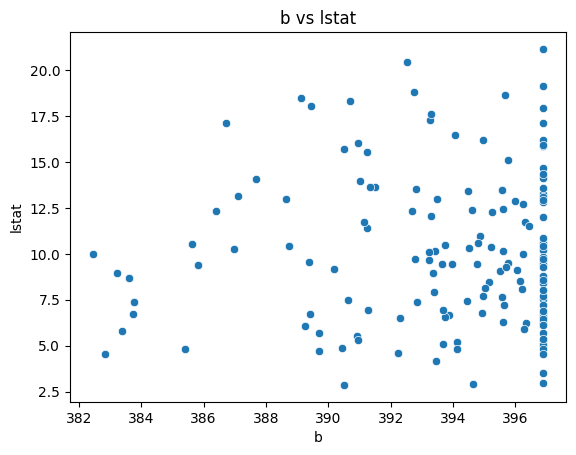

In [19]:
pairs = list(combinations(col_list, 2))
x = []
for i in pairs:
    if i not in x:
        x.append(i)
        if i[0] != 'medv' and i[1] != 'medv':
            plt.figure()
            sns.scatterplot(data=df, x= i[0], y=i[1])
            plt.title(f'{i[0]} vs {i[1]}')
            plt.show()

#### Multivarite Analysis

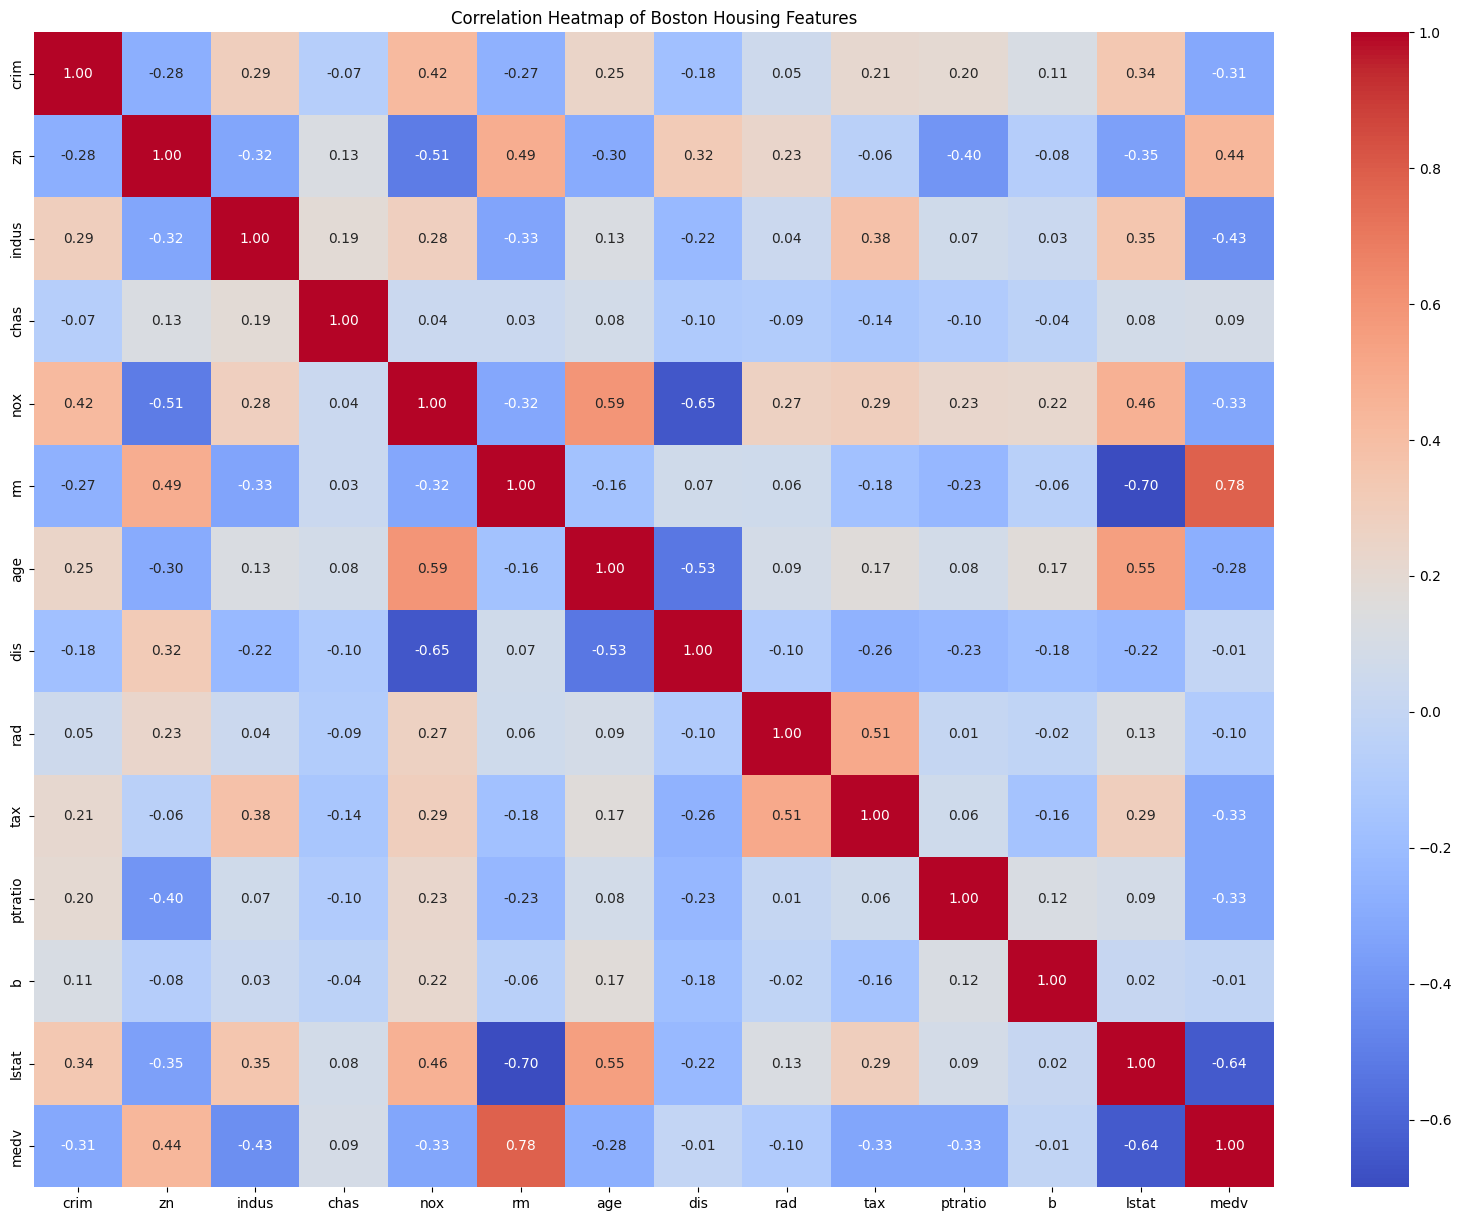

In [20]:
plt.figure(figsize=(20, 15))
corr_matrix = df[col_list].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Boston Housing Features")
plt.show()


# Regression model Build

In [21]:
# Imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

In [22]:
## split data in to x, y
x = df.drop(columns= 'medv')
y = df['medv']

In [23]:
# train and test spliting
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state= 5)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(109, 13)
(48, 13)
(109,)
(48,)


In [24]:
#building model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [25]:
model.coef_

array([ 2.98056802e+00,  1.38652594e-02, -3.18449510e-01,  1.37150730e+00,
       -1.36821998e+01,  7.25541347e+00, -5.87388847e-02, -1.05857675e+00,
        1.21304060e-01, -7.07977302e-03, -7.26502072e-01,  1.56789216e-02,
        7.31031829e-02])

In [26]:
model.intercept_

np.float64(2.6116499285936996)

In [27]:
y_pred = model.predict(x_test)
y_pred.round(2)

array([23.69, 26.51, 29.2 , 31.66, 20.67, 35.08, 25.56, 29.93, 18.41,
       19.07, 22.19, 24.57, 20.71, 20.  , 26.4 , 32.2 , 31.71, 29.59,
       19.84, 22.11, 23.82, 27.12, 23.84, 29.66, 32.59, 24.05, 33.92,
       25.05, 23.44, 32.62, 18.7 , 20.7 , 19.18, 21.67, 28.67, 23.25,
       22.13, 20.18, 22.79, 20.22, 21.51, 20.62, 30.94, 22.91, 25.21,
       21.73, 21.36, 18.16])

In [28]:
y_test

53     23.4
181    36.2
302    26.4
182    37.9
109    19.4
306    33.4
185    29.6
4      36.2
497    18.3
119    19.3
216    23.3
101    26.5
113    18.7
495    23.1
295    28.6
179    37.2
274    32.4
240    22.0
104    20.1
51     20.5
86     22.5
85     26.6
92     22.9
41     26.6
187    32.0
217    28.7
276    33.2
176    23.2
206    24.4
303    33.1
68     17.4
69     20.9
316    17.8
313    21.6
301    22.0
241    20.1
10     15.0
107    20.4
44     21.2
312    19.4
37     21.0
335    21.1
307    28.2
328    19.3
82     24.8
110    21.7
7      27.1
106    19.5
Name: medv, dtype: float64

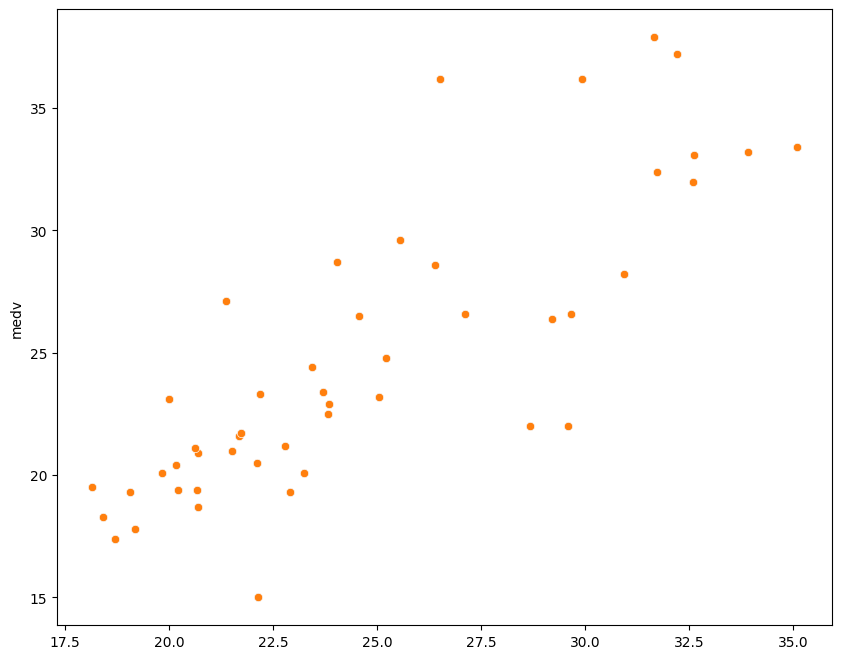

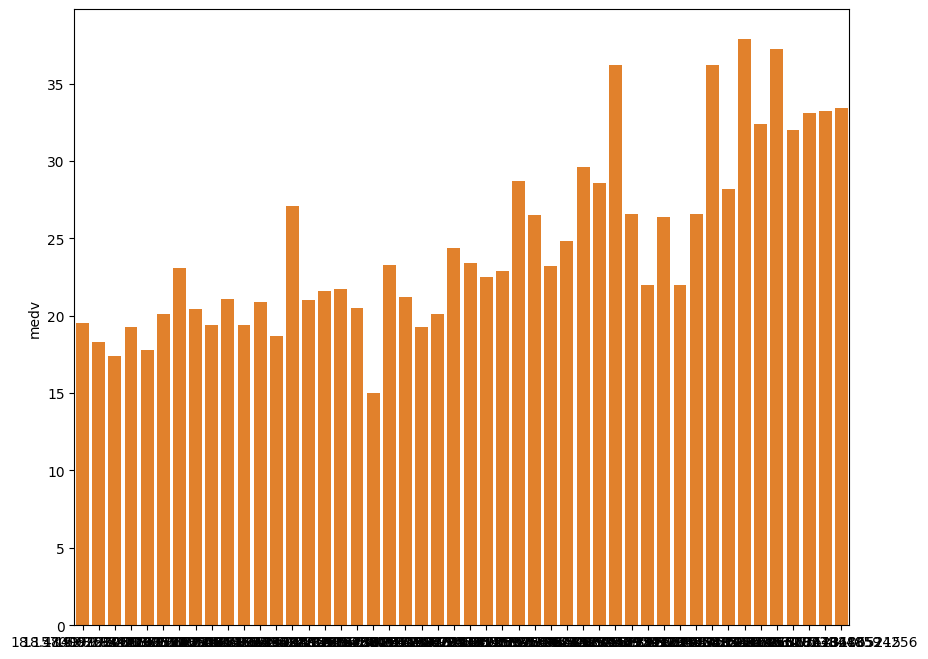

In [29]:
x = [sns.scatterplot, sns.barplot]
for i in x:
    plt.figure(figsize=(10, 8))
    i(x=y_pred, y=y_test)
    i(x=y_pred, y=y_test)
    plt.show()

In [30]:
for i in col_list:
    print(f'{i} , max : {round(df[i].max(), 2)} min: {round(df[i].min(), 2)}, mean : {round(df[i].mean(), 2)}')

crim , max : 0.49 min: 0.03, mean : 0.14
zn , max : 45.0 min: 0.0, mean : 8.52
indus , max : 15.04 min: 2.18, mean : 7.44
chas , max : 1 min: 0, mean : 0.06
nox , max : 0.58 min: 0.41, mean : 0.49
rm , max : 7.42 min: 5.39, mean : 6.25
age , max : 97.1 min: 2.9, mean : 54.45
dis , max : 8.06 min: 2.11, mean : 4.45
rad , max : 7 min: 3, mean : 4.64
tax , max : 432 min: 193, mean : 299.75
ptratio , max : 20.9 min: 14.9, mean : 18.15
b , max : 396.9 min: 382.44, mean : 393.74
lstat , max : 21.14 min: 2.87, mean : 10.06
medv , max : 37.9 min: 15.0, mean : 23.81


In [31]:
### Predict sales for new data for ideal settings
pred_col = []
for i in col_list:
    if i != 'medv':
        pred_col.append(i)

prdiction_new = pd.DataFrame([[0.01, 0.0, 11.13, 0.07, 0.39, 8.78, 2.9, 1.13, 9.55, 187, 22, 0.32, 1.73]], columns = pred_col)
model.predict(prdiction_new)

array([40.17603231])

# Model evaluation metrics

In [32]:
# mean squared error
mse = mean_squared_error(y_test, y_pred)
mse

10.784188548794743

In [33]:
r2 = r2_score(y_test, y_pred)
r2

0.678027692227251

In [34]:
mae = mean_absolute_error(y_test, y_pred)
mae

2.304697961064322

In [35]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

3.28392882821701

In [36]:
n = x_test.shape[0]   # number of samples
p = x_test.shape[1]   # number of features

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2


0.5549206333729646

### In this project, a multiple linear regression model was developed to predict the median house price (medv) using socio-economic, environmental, and housing-related features from the Boston Housing dataset. Exploratory Data Analysis (EDA) highlighted key relationships between house prices and important predictors such as average number of rooms (rm), percentage of lower status population (lstat), pupil–teacher ratio (ptratio), pollution levels (nox), and property tax rate (tax).

### After preprocessing and handling extreme values, the final model achieved an R² score of approximately 0.68, indicating that around 68% of the variance in house prices is explained by the selected features. The model recorded a Mean Squared Error (MSE) of ~10.78, a Root Mean Squared Error (RMSE) of ~3.28, and a Mean Absolute Error (MAE) of ~2.30, demonstrating a relatively low prediction error on the test dataset. These results suggest that the model’s predictions deviate from actual house prices by approximately $3,300 on average, which is a strong performance for a linear regression baseline on this dataset.

### While the linear regression model provides interpretable insights into the factors influencing house prices, its performance is inherently limited by the linear assumptions of the algorithm and the presence of correlations among predictor variables. Nevertheless, the achieved metrics indicate that the model captures the primary trends in the data effectively and serves as a reliable baseline for house price prediction.

### Overall, this work demonstrates a complete end-to-end regression workflow, including data cleaning, exploratory analysis, model training, and quantitative evaluation. The final model offers a solid foundation for further improvements using feature engineering, regularization techniques, or non-linear models in future iterations.